### HQ probes in OT NER data


* Define list of High Quality probes
* Find OT NEr subset with HQ probes
* Get all data for identified articles
* subset data for probe-target pairs (it has to be the correct target for the probe)
* Obtain triplets
* Improbe/update grounding
* Get grounded triplets

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator # Need FixedLocator for minor ticks

from collections.abc import Iterable # To check for list-like objects
import re
import seaborn as sns
from collections import Counter
import numpy as np
import requests
import time
pd.set_option('display.max_colwidth', 200)
from tools import ChemblDB, find_preferred_ta

pd.options.mode.chained_assignment = None 

In [2]:
#Counting probes in dictionary
hqprobes = pd.read_csv('data/probesSubset.csv', sep="\t")
#display(hqprobes)
nprobes = hqprobes.INCHI.nunique()
sprobes = hqprobes.assign(SYNOMS=hqprobes['SYNOMS'].str.split(',')).explode('SYNOMS').SYNOMS.nunique() 
print(nprobes, sprobes)


561 2797


In [3]:
display(hqprobes.columns)
hqprobes.PROBE.nunique()

Index(['SETID', 'UNIPROT', 'PROBE', 'SET', 'INCHI', 'GENE', 'CONTR',
       'CHEMBLID', 'PREF_NAME', 'SYNOMS', 'SYNOMS_TARGET'],
      dtype='object')

554

Probes in SGC (28): 101
Probes in Open Science (213): 112
Probes in ChemicalProbes Portal (408): 534
------------------------------


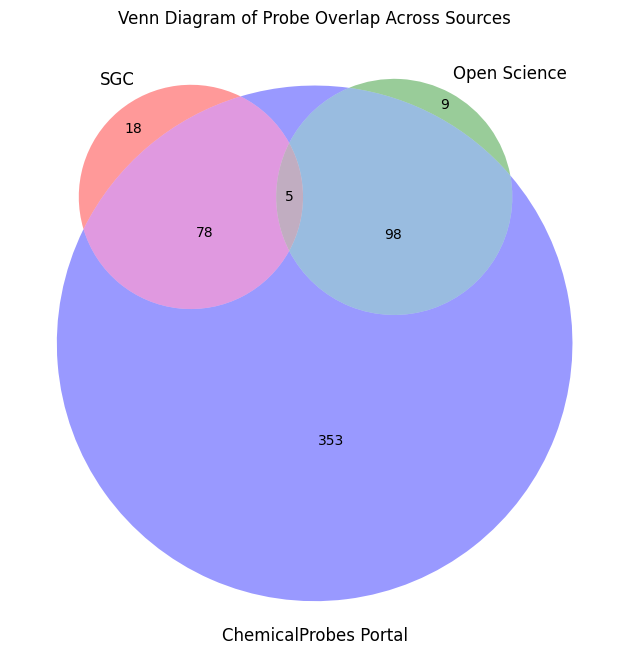

In [ ]:
#Plot showing source of probes

subs = hqprobes[['INCHI','SETID']].drop_duplicates()

main_source_1 = 28
main_source_2 = 213
main_source_3 = 408

# Give names to your sources for the plot labels
source_1_name = 'SGC'
source_2_name = 'Open Science'
source_3_name = 'ChemicalProbes Portal'

# --- 3. Create Sets of probeIds for Each Main Source ---
set1 = set()
set2 = set()
set3 = set()

# Iterate through the DataFrame rows
for index, row in subs.iterrows():
    probe_id = row['INCHI']
    sources_entry = row['SETID']

    # Check if the sources_entry is a list/iterable (and not a string)
    if isinstance(sources_entry, Iterable) and not isinstance(sources_entry, str):
        # It's a list (or similar)
        if main_source_1 in sources_entry:
            set1.add(probe_id)
        if main_source_2 in sources_entry:
            set2.add(probe_id)
        if main_source_3 in sources_entry:
            set3.add(probe_id)
    else:
        # It's a single value
        if sources_entry == main_source_1:
            set1.add(probe_id)
        elif sources_entry == main_source_2:
            set2.add(probe_id)
        elif sources_entry == main_source_3:
            set3.add(probe_id)

print(f"Probes in {source_1_name} ({main_source_1}): {len(set1)}")
print(f'Probes in {source_2_name} ({main_source_2}): {len(set2)}')
print(f'Probes in {source_3_name} ({main_source_3}): {len(set3)}')
print("-" * 30)

# --- 4. Generate and Display the Venn Diagram ---
plt.figure(figsize=(10, 8)) # Adjust figure size as needed

# Create the Venn diagram using the sets
# venn3 automatically calculates the sizes of the intersections and unique parts
v = venn3(
    [set1, set2, set3],
    set_labels=(source_1_name, source_2_name, source_3_name)
)

plt.title('Venn Diagram of Probe Overlap Across Sources')
plt.savefig('figs/supp_vd_sources.png')
plt.show()


In [ ]:
#numbers for initial dataset
#numbers1 = pd.read_csv('data/epmc_ner_results_hq_probes_all_sent.tsv', sep='\t')
#print(numbers1.pmid.nunique())
#print(numbers1.label.nunique())
#print(numbers1.label_id.nunique())
#print(numbers1.label[numbers1.label.str.startswith('CHEMBL', na=False)].unique()) #Labels include all labels either compoun, target, phenotype

In [5]:
#Reading triplets data
ner_triplets = pd.read_csv('data/2_ner_probes_triplets.tsv', sep="\t", dtype={'pmid': 'str', 'date':'str', 'section':'str', 'CD':'str', 'GP': 'str', 'DS':'str', 'sentence':'str'})

In [6]:
#Reading triplets with evidence data and drug max phase if available data
ner_triplets_ptpairs = pd.read_csv('data/7_ner_probes_triplets_ptpairs_dr.tsv', sep="\t")

print(len(ner_triplets_ptpairs))

820933


In [7]:
display(ner_triplets_ptpairs.head(1))

,diseaseId,targetId,datasourceId,allcurationYears,allpublicationYears,allstudyYears,datatypeId,score,evidenceCount,pmid,...,gene,control,prefName,probeSyn,targetSyn,name,therapeuticAreas,drugId,phase,status
0,DOID_7551,ENSG00000121879,europepmc,NaN,"[2021, 2016, 2014, 2012, 2019, 2020, 2023, 2013, 2018, 2022, 2015, 2011, 2017]",NaN,literature,0.515801,135.0,31662821,...,PIK3CA,NaN,ALPELISIB,"VIJOICE, A-1214, Byl-719, (S)-N1-(4-Methyl-5-(2-(1,1,1-trifluoro-2-methylpropan-2-yl)pyridin-4-yl)thiazol-2-yl)pyrrolidine-1,2-dicarboxamide, Alpelisib (BYL719), NVP-BYL719, Vijoice, Piqray, PIQRA...","Phosphoinositide 3-kinase alpha, Phosphatidylinositol 4,5-bisphosphate 3-kinase 110 kDa catalytic subunit alpha, PI3K-alpha, PI3-kinase subunit alpha, Phosphoinositide-3-kinase catalytic alpha pol...",gonorrhea,EFO_0005741|OTAR_0000017,NaN,NaN,NaN


In [8]:
#showing numbers for any probe-target found
print('any probe-target')
print(len(ner_triplets))
for col in ner_triplets:
    print(col, ner_triplets[col].nunique())
print('\n')

#showing numbers for the spcific known target for the probe
print('specific probe-target')
print(len(ner_triplets_ptpairs))
for col in ner_triplets_ptpairs:
    print(col, ner_triplets_ptpairs[col].nunique())

any probe-target
316396
diseaseId 924
targetId 151
datasourceId 23
allcurationYears 33
allpublicationYears 1403
allstudyYears 330
datatypeId 7
score 3005
evidenceCount 490
pmid 16173
date 1566
section 27
probeId 181
sentence 30027
setId 3
uniprot 440
probe 181
set 3
inchiKey 181
gene 151
control 34
prefName 135
probeSyn 195
targetSyn 333
name 920
therapeuticAreas 304
drugId 316
phase 5
status 9


specific probe-target
820933
diseaseId 1352
targetId 161
datasourceId 23
allcurationYears 73
allpublicationYears 3545
allstudyYears 790
datatypeId 7
score 6997
evidenceCount 851
pmid 19999
date 1932
section 27
probeId 194
sentence 39124
setId 3
uniprot 463
probe 194
set 3
inchiKey 194
gene 161
control 39
prefName 141
probeSyn 211
targetSyn 353
name 1348
therapeuticAreas 413
drugId 356
phase 5
status 9


In [9]:
print(ner_triplets_ptpairs.pmid.nunique(), ner_triplets_ptpairs.probe.nunique(), ner_triplets_ptpairs.targetId.nunique(), ner_triplets_ptpairs.diseaseId.nunique() )

19999 194 161 1352


In [10]:
ner_triplets_ptpairs.columns

Index(['diseaseId', 'targetId', 'datasourceId', 'allcurationYears',
       'allpublicationYears', 'allstudyYears', 'datatypeId', 'score',
       'evidenceCount', 'pmid', 'date', 'section', 'probeId', 'sentence',
       'setId', 'uniprot', 'probe', 'set', 'inchiKey', 'gene', 'control',
       'prefName', 'probeSyn', 'targetSyn', 'name', 'therapeuticAreas',
       'drugId', 'phase', 'status'],
      dtype='object')

#### Max phase of the chemical probe

In [11]:
#Getting clinical phase for probes
chembl = ChemblDB('/Users/adasme/Documents/codes/chembl_35/chembl_35_sqlite/chembl_35.db')
ner_triplets_ptpairs['maxPhase'] = ner_triplets_ptpairs.probeId.map(lambda x: chembl.get_max_phase(x)[0]).astype('Int64').replace({np.nan: None})
ner_triplets_ptpairs.groupby('maxPhase')['probeId'].nunique()

maxPhase
1    27
2    39
3    11
4    34
Name: probeId, dtype: int64

In [12]:
# Non drugs probes
drugprobes = ner_triplets_ptpairs[~ner_triplets_ptpairs.maxPhase.isnull()]
nondrugs = ner_triplets_ptpairs[ner_triplets_ptpairs.maxPhase.isnull()]
print(drugprobes.probeId.nunique())
print(nondrugs.probeId.nunique())
print(len(drugprobes[['targetId', 'diseaseId']].drop_duplicates()))
print(len(nondrugs[['targetId', 'diseaseId']].drop_duplicates()))

111
83
4823
839


In [13]:
#Subset with target-disease pairs having 100 or more articles found (probably to be used to construct a netweor)
subs2 = ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.str.startswith(('EFO', 'MONDO', 'HP'), na=False)][['targetId', 'diseaseId', 'probeId', 'pmid']]
#print(subs.head())

# 1. Aggregate data
grouped_data2 = subs2.groupby(['targetId', 'diseaseId']).agg(
    pmid_count=('pmid', pd.Series.nunique),
    probeId_count=('probeId', pd.Series.nunique)
).reset_index()

grouped_data2 = grouped_data2[grouped_data2.pmid_count>=100]
display(grouped_data2.sort_values(by='probeId_count',ascending=False).head())
print(len(grouped_data2))
grouped_data2.to_csv("/Users/adasme/Documents/codes/probes_articles/figs/tables/subset_100freq.tsv", sep='\t', index=False)

,targetId,diseaseId,pmid_count,probeId_count
1253,ENSG00000106462,EFO_0000616,247,5
1354,ENSG00000106462,MONDO_0004992,123,5
1247,ENSG00000106462,EFO_0000403,100,5
2728,ENSG00000143799,MONDO_0004992,141,5
2665,ENSG00000143799,EFO_0000616,164,5


61


#### Sections in articles

,section,counts
0,abbr,98
1,abstract,7936
2,ack_fund,13
3,auth_cont,2
4,case,47
5,concl,1529
6,discuss,10048
7,fig,621
8,intro,9352
9,methods,2746


/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_31789/4131460305.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['section'], rotation=45, ha='right')


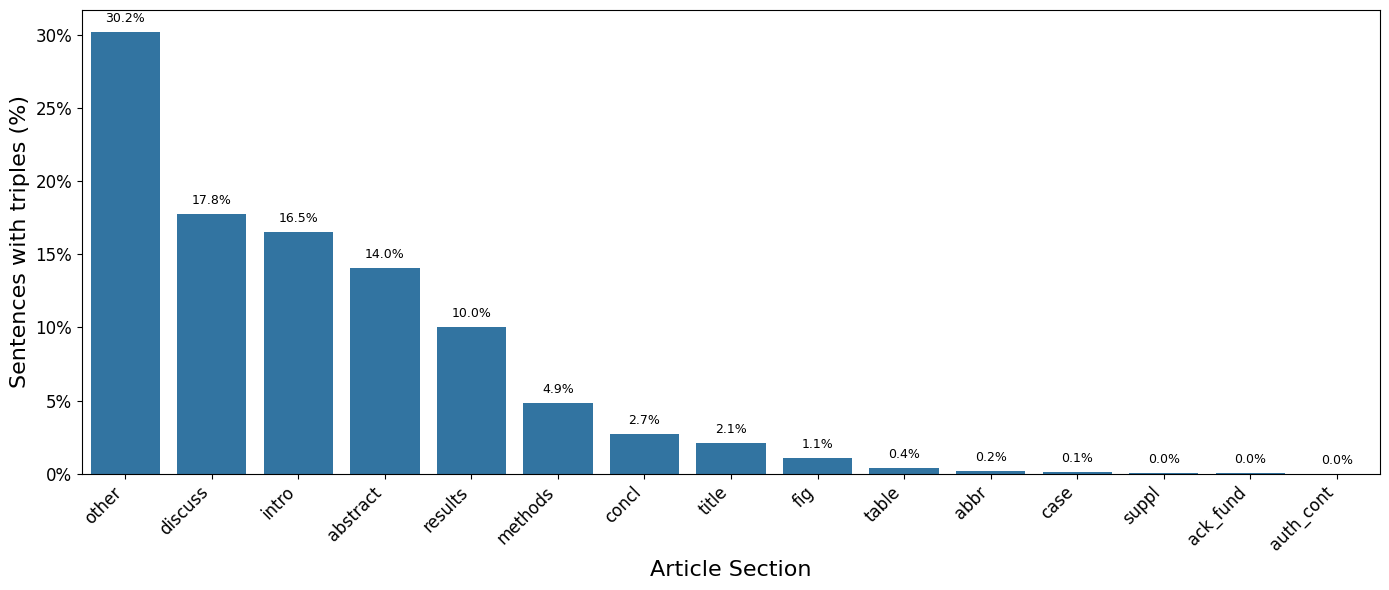

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter # Import the formatter

# 1. Ensure the 'section' column is string type and handle potential missing values
articles = ner_triplets_ptpairs[['diseaseId', 'targetId','pmid','section', 'probeId', 'sentence']].drop_duplicates().dropna(subset=['section']).copy() # Drop rows where section is NaN
articles['section'] = articles['section'].astype(str) 

# 2. Split the 'section' string by comma into a list of strings
#    Use str.strip() within a list comprehension to remove leading/trailing whitespace 
#    from each section name after splitting.
articles['section'] = articles['section'].str.split(',').apply(lambda x: [item.strip() for item in x])

# 3. Explode the DataFrame based on the 'section' list
#    This creates a new row for each item in the list in the 'section' column,
#    duplicating the other column values for that original row.
articles_exploded = articles.explode('section')

secs = articles_exploded.drop_duplicates().groupby('section')['sentence'].count().reset_index(name='counts')
display(secs)
df = secs.sort_values('counts', ascending=False)


# --- New: Calculate percentages ---
total_counts = df['counts'].sum()
df['percentage'] = (df['counts'] / total_counts) * 100

# --- Plotting Code ---
plt.figure(figsize=(14, 6))

# --- Modified: Use 'percentage' for the y-axis ---
ax = sns.barplot(x='section', y='percentage', data=df)

# Rotate x-axis labels
ax.tick_params(axis='x', rotation=45)

# --- Modified: Format Y-axis to show percentages ---
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))

# --- Modified: Set Y-axis label to indicate percentage ---
ax.set_ylabel("Sentences with triples (%)", fontsize=16)
ax.set_xlabel("Article Section", fontsize=16)

# This part needs to be adjusted based on the actual sections in your data
# For the sample data, we'll get the labels from the DataFrame
ax.set_xticklabels(df['section'], rotation=45, ha='right')


# Increase font size for tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# --- Modified: Add annotations with percentage values ---
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='bottom',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=9)

# Adjust layout
plt.tight_layout() 

plt.savefig("figs/sections.png", dpi=400)
# Display the plot
plt.show()

In [15]:
# Examples with sentences found in the "Other" category of the article sections
articles_exploded[articles_exploded.section == 'other'][['pmid','sentence']].head(10)

,pmid,sentence
0,31662821,"A clinical trial (NCT01613950) was performed to investigate the efficacy of the combination of alpelisib (BYL719), a potent and selective inhibitor of mutated PI3KCA and AUY922, an inhibitor of he..."
1,33321820,"Some clinical trials of PI3K inhibitors (BKM120, BYL719, and GSK2636771) and Akt inhibitors (MK2206, GSK2110183, and GDC-0068; Table 3) have been performed in patients with advanced and metastatic..."
5,26267324,"To date, two classes of PI3K inhibitors have been evaluated for the treatment of GC: pan-PI3K inhibitors, which target all PI3K family members (BKM120, PX-886, and XL147), and isoform-specific PI3..."
8,38339127,"A phase IB, multicenter, open-label dose escalation study tested the antitumoral effects of BYL719 (PI3K inhibitor) in combination with AUY922 (HSP90 inhibitor) in advanced or metastatic GC patien..."
17,26267324,"Currently, the isoform-specific p110α inhibitor, BYL719, and the heat shock protein 90 inhibitor, AUY922, are being evaluated in a phase I trial with advanced stage GC patients that carry either a..."
45,28008224,"Flavopiridol, the first Cdk inhibitor used in clinical trials, inhibits in vitro cell growth by targeting Cdk2, Cdk4, and Cdk6 in G1-S or G2-M phases of the cell cycle.118,119 In addition, flavopi..."
46,28008224,"Flavopiridol, the first Cdk inhibitor used in clinical trials, inhibits in vitro cell growth by targeting Cdk2, Cdk4, and Cdk6 in G1-S or G2-M phases of the cell cycle.118,119 In addition, flavopi..."
86,28008224,"Flavopiridol, the first Cdk inhibitor used in clinical trials, inhibits in vitro cell growth by targeting Cdk2, Cdk4, and Cdk6 in G1-S or G2-M phases of the cell cycle.118,119 In addition, flavopi..."
89,27529512,"Thus, with the exception of flavopiridol for the treatment of chronic lymphocytic leukaemia (Lin et al, 2009), where the transcriptional kinase CDK9 is thought to be the primary target, and palboc..."
91,28008224,"Flavopiridol, the first Cdk inhibitor used in clinical trials, inhibits in vitro cell growth by targeting Cdk2, Cdk4, and Cdk6 in G1-S or G2-M phases of the cell cycle.118,119 In addition, flavopi..."


#### Getting table with triplets (should be adapted to data)

In [16]:
grouped_df = ner_triplets_ptpairs.groupby(['probe', 'targetId']).agg({
    'diseaseId': lambda x: ', '.join([f'{item}[{count}]' for item, count in Counter(x).items()]),
    'pmid': 'nunique'
}).sort_values(by=['pmid']).reset_index()

# Rename aggregated columns
#grouped_df.columns = ['PROBE', 'GENE', 'ALL_DISEASES', 'ARTICLES']
grouped_df = grouped_df.rename(columns={'pmid':'articles'})
#display(grouped_df)

In [17]:
ner_triplets_ptpairs[ner_triplets_ptpairs.probe.str.startswith('GSK')]
#CHEMBL1957266

,diseaseId,targetId,datasourceId,allcurationYears,allpublicationYears,allstudyYears,datatypeId,score,evidenceCount,pmid,...,control,prefName,probeSyn,targetSyn,name,therapeuticAreas,drugId,phase,status,maxPhase
2009,EFO_0000182,ENSG00000106462,cancer_gene_census,NaN,[2017],NaN,somatic_mutation,0.455948,1.0,26973856,...,NaN,NaN,"Lirametostat, Cpi-1205, Ezh2 inhibitor cpi-1205, GSK-343, GSK 343, GSK343, CPI-1205","KMT6, Enhancer of zeste homolog 2, Lysine N-methyltransferase 6, ENX1H, Histone-lysine N-methyltransferase EZH2, EZH2, ENX-1, 2.1.1.356",hepatocellular carcinoma,EFO_0001379|MONDO_0045024|EFO_0010282,NaN,NaN,NaN,None
2016,EFO_0000182,ENSG00000106462,cancer_gene_census,NaN,[2017],NaN,somatic_mutation,0.455948,1.0,30035186,...,NaN,NaN,"GSK343, GW788388, GSK-343, GSK 343","KMT6, Enhancer of zeste homolog 2, Lysine N-methyltransferase 6, ENX1H, Histone-lysine N-methyltransferase EZH2, EZH2, ENX-1, 2.1.1.356",hepatocellular carcinoma,EFO_0001379|MONDO_0045024|EFO_0010282,NaN,NaN,NaN,None
2019,EFO_0000182,ENSG00000106462,cancer_gene_census,NaN,[2017],NaN,somatic_mutation,0.455948,1.0,30035186,...,NaN,NaN,"Lirametostat, Cpi-1205, Ezh2 inhibitor cpi-1205, GSK-343, GSK 343, GSK343, CPI-1205","KMT6, Enhancer of zeste homolog 2, Lysine N-methyltransferase 6, ENX1H, Histone-lysine N-methyltransferase EZH2, EZH2, ENX-1, 2.1.1.356",hepatocellular carcinoma,EFO_0001379|MONDO_0045024|EFO_0010282,NaN,NaN,NaN,None
2020,EFO_0000182,ENSG00000106462,cancer_gene_census,NaN,[2017],NaN,somatic_mutation,0.455948,1.0,26973856,...,NaN,NaN,"GSK343, GW788388, GSK-343, GSK 343","KMT6, Enhancer of zeste homolog 2, Lysine N-methyltransferase 6, ENX1H, Histone-lysine N-methyltransferase EZH2, EZH2, ENX-1, 2.1.1.356",hepatocellular carcinoma,EFO_0001379|MONDO_0045024|EFO_0010282,NaN,NaN,NaN,None
2025,EFO_0000182,ENSG00000106462,cancer_gene_census,NaN,[2017],NaN,somatic_mutation,0.455948,1.0,26973856,...,NaN,NaN,"GSK343, GW788388, GSK-343, GSK 343","KMT6, Enhancer of zeste homolog 2, Lysine N-methyltransferase 6, ENX1H, Histone-lysine N-methyltransferase EZH2, EZH2, ENX-1, 2.1.1.356",hepatocellular carcinoma,EFO_0001379|MONDO_0045024|EFO_0010282,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820928,Orphanet_92050,ENSG00000111199,europepmc,NaN,"[2017, 2019]",NaN,literature,0.162959,3.0,28542130,...,NaN,NaN,"GSK1016790A, GSK101, AZC5363, Azd 5363, Azd-5363, Truqap, Capivasertib, GSK 1016790A, AZD-5363, AZD5363","VRL2, TrpV4, Trp12, Transient receptor potential protein 12, Vanilloid receptor-related osmotically-activated channel, Transient receptor potential cation channel subfamily V member 4, TRP12, VROA...",Intestinal epithelial dysplasia,OTAR_0000018|EFO_0010282,NaN,NaN,NaN,None
820929,Orphanet_92050,ENSG00000111199,europepmc,NaN,"[2017, 2019]",NaN,literature,0.162959,3.0,28542130,...,NaN,NaN,"GSK1016790A, GSK101, AZC5363, Azd 5363, Azd-5363, Truqap, Capivasertib, GSK 1016790A, AZD-5363, AZD5363","VRL2, TrpV4, Transient receptor potential protein 12, Vanilloid receptor-related osmotically-activated channel, Transient receptor potential cation channel subfamily V member 4, TRP12, VROAC, Trpv...",Intestinal epithelial dysplasia,OTAR_0000018|EFO_0010282,NaN,NaN,NaN,None
820930,Orphanet_92050,ENSG00000111199,europepmc,NaN,"[2017, 2019]",NaN,literature,0.162959,3.0,28542130,...,NaN,NaN,"GSK1016790A, GSK101, AZC5363, Azd 5363, Azd-5363, Truqap, Capivasertib, GSK 1016790A, AZD-5363, AZD5363","VRL2, TrpV4, Transient receptor potential protein 12, Vanilloid receptor-related osmotically-activated channel, Transient receptor potential cation channel subfamily V member 4, TRP12, VROAC, Trpv...",Intestinal epithelial dysplasia,OTAR_0000018|EFO_0010282,NaN,NaN,NaN,None
820931,Orphanet_92050,ENSG00000111199,europepmc,NaN,"[2017, 2019]",NaN,literature,0.162959,3.0,28542130,...,NaN,NaN,"GSK1016790A, GSK101, AZC5363, Azd 5363, Azd-5363, Truqap, Capivasertib, GSK 1016790A, AZD-5363, AZD5363","VRL2, TrpV4, Trp12, T

In [18]:
# 1. Create a temporary combined column so the Phase stays attached to the Probe
ner_triplets_ptpairs['probe_data'] = list(zip(ner_triplets_ptpairs['probeId'], ner_triplets_ptpairs['maxPhase']))

# 2. Perform the aggregation on this new combined column
grouped_df2 = ner_triplets_ptpairs.groupby(['targetId', 'diseaseId']).agg({
    # We count the unique (Probe, Phase) tuples
    'probe_data': lambda x: ', '.join([f'{pid} ({phase})[{count}]' for (pid, phase), count in Counter(x).items()]),
    'pmid': 'nunique'
}).sort_values(by=['pmid']).reset_index()

# 3. Rename and Clean up
grouped_df2 = grouped_df2.rename(columns={'pmid': 'articles', 'probe_data': 'probe_summary'})

sample = grouped_df2.sort_values(by='articles', ascending=False).head(100)
display(sample)

,targetId,diseaseId,probe_summary,articles
5520,ENSG00000146648,EFO_0003060,"CHEMBL1173655 (4)[71952], CHEMBL5194790 (None)[24]",1260
5519,ENSG00000198793,EFO_0000616,"CHEMBL413 (4)[31806], CHEMBL1801204 (1)[2835], CHEMBL1922094 (2)[837], CHEMBL2336325 (2)[1161]",978
5518,ENSG00000198793,MONDO_0004992,"CHEMBL413 (4)[24867], CHEMBL1922094 (2)[459], CHEMBL1801204 (1)[1026], CHEMBL2336325 (2)[351]",825
5517,ENSG00000171791,EFO_0000222,CHEMBL3137309 (4)[19290],807
5516,ENSG00000171094,EFO_0003060,CHEMBL1738797 (4)[27852],804
...,...,...,...,...
5423,ENSG00000066468,EFO_0000616,CHEMBL1852688 (4)[2054],61
5425,ENSG00000096968,EFO_0000616,"CHEMBL1789941 (4)[2790], CHEMBL221959 (4)[270], CHEMBL2107823 (2)[90], CHEMBL3545215 (2)[180]",61
5424,ENSG00000182578,MONDO_0018177,CHEMBL3813873 (4)[453],61
5422,ENSG00000105639,EFO_0003778,CHEMBL221959 (4)[372],59


In [19]:
# --- Mapping the probe names ---
run=True
if run:
    # We use drop_duplicates to ensure 1:1 mapping and avoid merge explosions
    probe_dictionary = ner_triplets_ptpairs.drop_duplicates('probeId').set_index('probeId')['probe'].to_dict()
    target_dictionary = ner_triplets_ptpairs.drop_duplicates('targetId').set_index('targetId')['gene'].to_dict()
    disease_dictionary = ner_triplets_ptpairs.drop_duplicates('diseaseId').set_index('diseaseId')['name'].to_dict()

    # Assume sample['probe_summary'] contains strings like: "CHEMBL123 (Phase 2)[5]"
    col_to_process = 'probe_summary' if 'probe_summary' in sample.columns else 'probeId'
    sample_exploded = sample[col_to_process].str.split(', ').explode().str.strip()
    def get_mapped_name(probe_entry):
        # Regex Explanation:
        # ([^\s\[]+)  -> Group 1: Capture the ID (everything before the first space or bracket)
        # (.*)        -> Group 2: Capture the rest (e.g., " (Phase 4)[10]" or just "[10]")
        match = re.match(r'([^\s\[]+)(.*)', str(probe_entry))
        if match:
            probe_id, suffix_info = match.groups()
            # Look up the name, default to ID if missing
            raw_name = probe_dictionary.get(probe_id, probe_id)
            probe_name = str(raw_name).capitalize()
            # Return Name + the preserved Phase/Count info
            return f"{probe_name}{suffix_info}"
        return probe_entry

    mapped_probes = sample_exploded.apply(get_mapped_name)

    # Group back together
    aggregated_names = mapped_probes.groupby(level=0).agg(', '.join)
    sample['Chemical probe (max phase)[sentences]'] = aggregated_names

    # --- 3. Map Target and Disease Names safely ---
    # Using .map() is safer than .merge() here as it preserves the exact row count of 'sample'
    sample['Target'] = sample['targetId'].map(target_dictionary).fillna(sample['targetId'])
    sample['Disease'] = sample['diseaseId'].map(disease_dictionary).fillna(sample['diseaseId'])

    # --- 4. Display and Export ---
    print("DataFrame with Mapped Names and Phases:")
    cols_to_export = ['Target', 'Disease', 'Chemical probe (max phase)[sentences]', 'articles']
    display(sample['Chemical probe (max phase)[sentences]'].head(20))

    sample[cols_to_export].to_csv('tables/ner_target_disease_pairs_hr.csv', sep='\t', index=False)

DataFrame with Mapped Names and Phases:


5520                                                 Afatinib (4)[71952], Sjf1528 (None)[24]
5519    Sirolimus (4)[31806], Azd-8055 (1)[2835], Apitolisib (2)[837], Vistusertib (2)[1161]
5518     Sirolimus (4)[24867], Apitolisib (2)[459], Azd-8055 (1)[1026], Vistusertib (2)[351]
5517                                                                   Venetoclax (4)[19290]
5516                                                                    Alectinib (4)[27852]
5515                                                                   Venetoclax (4)[16110]
5514                                           Palbociclib (4)[21384], Abemaciclib (4)[7722]
5513                                                Afatinib (4)[26554], Sjf1528 (None)[102]
5512                          Ruxolitinib (4)[2016], Tofacitinib (4)[96], Filgotinib (4)[12]
5511                          Ruxolitinib (4)[2016], Tofacitinib (4)[96], Filgotinib (4)[12]
5510                         Ruxolitinib (4)[102], Tofacitinib (4)[676

#### Getting plot with Disease-target pairs (should be adapted to data)

3946 1


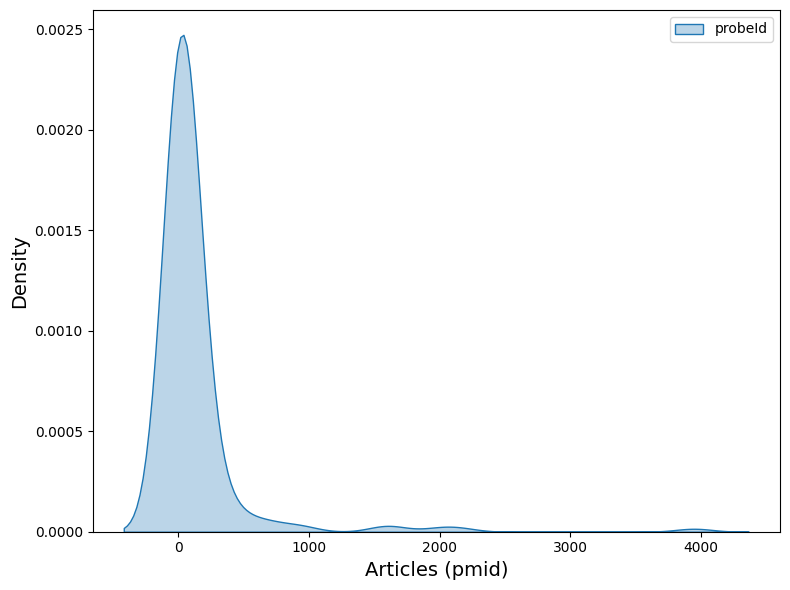

In [20]:
# Loop through the columns you want to plot
gr = ner_triplets_ptpairs.groupby('probeId').agg({'pmid': 'nunique'}).sort_values(by=['pmid']).reset_index()
print(gr.pmid.max(), gr.pmid.min())


# Create the figure and axes
plt.figure(figsize=(8, 6)) # Optional: Adjust figure size
# Use sns.kdeplot, specifying the data column and adding a label
sns.kdeplot(gr, x='pmid', label='probeId', fill=True, alpha=0.3, common_norm=False) # 'fill' adds shading
    

plt.xlabel('Articles (pmid)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("figs/ner_probes_pmid_distribution.png", dpi=400)
plt.savefig("figs/ner_probes_pmid_distribution.svg", dpi=400)
plt.show()

In [21]:
probe_dis = ner_triplets_ptpairs.groupby('probeId')[['targetId','diseaseId']].nunique().sort_values(by=['targetId']).reset_index()
print(probe_dis.targetId.min(),probe_dis.targetId.max(),probe_dis.targetId.median(),probe_dis.diseaseId.min(),probe_dis.diseaseId.max(),probe_dis.diseaseId.median())
#probe_dis = ner_triplets_ptpairs.groupby('probeId').agg({'diseaseId': 'nunique'}).sort_values(by=['pmid']).reset_index()

1 5 1.0 1 743 10.0


/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_31789/3730753049.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=probe_dis,
/var/folders/1h/mvhd393j60q_lnyl0qsdgkgw0000gp/T/ipykernel_31789/3730753049.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=probe_dis,


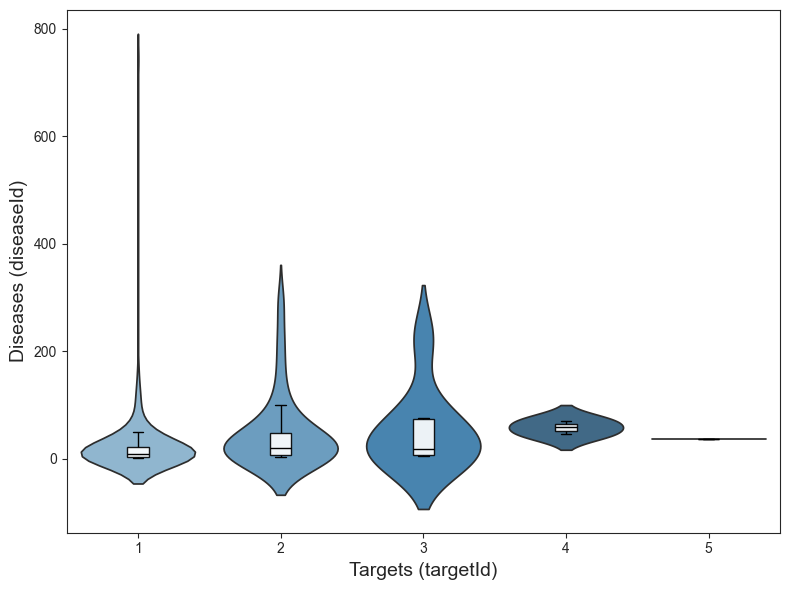

In [22]:
# Set the aesthetic style
sns.set_style("ticks")

# Create the figure and axes
plt.figure(figsize=(8, 6)) # Optional: Adjust figure size
ax = plt.gca() # Get the current axes

# 1. Create the violin plot WITHOUT the inner element
sns.violinplot(data=probe_dis,
               x='targetId',
               y='diseaseId',
               inner=None,       # Draw violin shape only
               palette='Blues_d',# Use the palette for violin color
               ax=ax)            # Specify the axes to draw on

# 2. Overlay the boxplot with custom styling
sns.boxplot(data=probe_dis,
            x='targetId',
            y='diseaseId',
            showfliers=False,   # Hide outliers here (violin shows full range)
            width=0.15,         # Make boxes narrow to fit inside violins
            palette='Blues_d',  # Use same palette for consistency (optional)
            boxprops=dict(facecolor='white', edgecolor='black', alpha=0.9), # *** Set facecolor to white ***
            medianprops=dict(color='black'), # Style median line
            whiskerprops=dict(color='black'),# Style whiskers
            capprops=dict(color='black'),    # Style caps
            ax=ax)              # Specify the same axes

# Improve appearance
sns.despine()

# Set labels and layout
plt.xlabel('Targets (targetId)', fontsize=14)
plt.ylabel('Diseases (diseaseId)', fontsize=14)

# --- Ensure all four spines are visible to form a box ---
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.tight_layout()


# Save and show the figure (updated filename)
plt.savefig("figs/ner_probe_tar_dis_distribution.png", dpi=400)
plt.savefig("figs/ner_probe_tar_dis_distribution.svg", dpi=400)
plt.show()

In [23]:
#checking the 3 most frequents disease in the heatmap
grt = ner_triplets_ptpairs.groupby(['diseaseId']).agg({'targetId': 'nunique'}).sort_values(by=['targetId']).reset_index()
print(grt[grt.diseaseId.isin(['EFO_0003060','EFO_0000616','MONDO_0004992'])])

          diseaseId  targetId
1346    EFO_0003060        58
1350  MONDO_0004992        97
1351    EFO_0000616       106


In [24]:
gr = ner_triplets_ptpairs.groupby(['targetId', 'diseaseId']).agg({'pmid': 'nunique'}).sort_values(by=['pmid']).reset_index()
print(gr.pmid.min(),gr.pmid.max())
grs = gr[gr.pmid>50]
#display(grs)
print(grs.targetId.nunique(), grs.diseaseId.nunique())
pivot_table = grs.pivot_table(index="targetId", columns="diseaseId", values="pmid")

1 1260
28 44


,targetId,diseaseId,pmid_count,probeId_count
1354,ENSG00000106462,MONDO_0004992,123,5
1888,ENSG00000129484,EFO_0000616,22,5
1899,ENSG00000129484,MONDO_0004992,32,5
2225,ENSG00000135679,EFO_0000616,138,5
2728,ENSG00000143799,MONDO_0004992,141,5


<Axes: xlabel='pmid_count', ylabel='Count'>

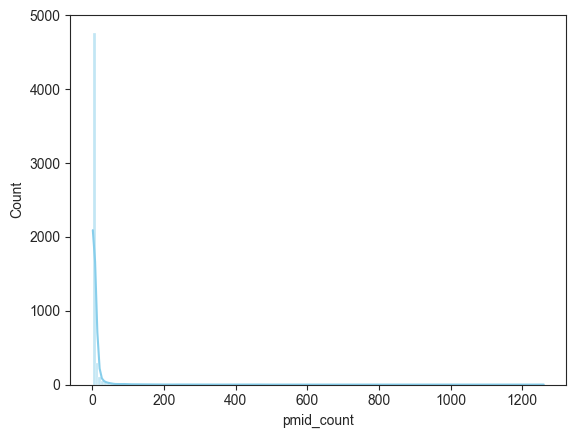

In [25]:
subs = ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.str.startswith(('EFO', 'MONDO', 'HP'), na=False)][['targetId', 'diseaseId', 'probeId', 'pmid']]
#print(subs.head())

# 1. Aggregate data
grouped_data = subs.groupby(['targetId', 'diseaseId']).agg(
    pmid_count=('pmid', pd.Series.nunique),
    probeId_count=('probeId', pd.Series.nunique)
).reset_index()
display(grouped_data.sort_values(by='probeId_count',ascending=False).head())

sns.histplot(data=grouped_data, x='pmid_count', kde=True, color="skyblue", bins=160)

In [26]:
interesting = gr[gr.pmid>500]
#display(interesting.sort_values(by='pmid'))

### NUMBERS

In [27]:
#display(ner_triplets_ptpairs.columns)
# plotting eevidence general
dfcounts = ner_triplets_ptpairs.copy()

# Combine 'TARGET' and 'DISEASE' columns into 'TARGET-DISEASE'
dfcounts['target-disease'] = dfcounts['targetId'] + '-' + dfcounts['diseaseId']

### Most frequent chemical probes

In [28]:
first_probes = dfcounts.groupby('probeId')['probe'].first().reset_index()
# Count unique PMIDs per probeId
unique_pmids = dfcounts.groupby('probeId')['pmid'].nunique().reset_index(name='pmids')
# Merge the results
result_df = pd.merge(unique_pmids, first_probes, on='probeId')
#display(result_df.sort_values(by=['pmids'], ascending=False))

### Most frequent diseases

In [29]:
print(ner_triplets_ptpairs.diseaseId.nunique())
# Cleaning redundant dieases
ner_triplets_ptpairs['diseaseId'] = ner_triplets_ptpairs['diseaseId'].str.replace('EFO_0000519', 'MONDO_0018177', regex=False)
ner_triplets_ptpairs['name'] = ner_triplets_ptpairs['name'].str.replace('glioblastoma multiforme', 'glioblastoma', regex=False)
result_df = dfcounts.groupby('diseaseId')['pmid'].nunique().reset_index(name='pmids')
dis_freq = result_df.sort_values(by=['pmids'], ascending=False).head(34).diseaseId.tolist()
#print(ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.isin(dis_freq)][['diseaseId', 'name']].drop_duplicates())


1352


### Most frequent targets

In [30]:
print(ner_triplets_ptpairs.targetId.nunique())
result_tdf = dfcounts.groupby('targetId')['pmid'].nunique().reset_index(name='pmids')
tar_freq = result_tdf.sort_values(by=['pmids'], ascending=False).head(30).targetId.tolist()
#print(ner_triplets_ptpairs[ner_triplets_ptpairs.targetId.isin(tar_freq)][['targetId', 'gene']].drop_duplicates())

161


### Clustering diseasea according to ontology

In [31]:
from tools import find_preferred_ta
ner_triplets_ptpairs['preferredTA'] = ner_triplets_ptpairs['therapeuticAreas'].apply(find_preferred_ta)
print(ner_triplets_ptpairs.columns)

Index(['diseaseId', 'targetId', 'datasourceId', 'allcurationYears',
       'allpublicationYears', 'allstudyYears', 'datatypeId', 'score',
       'evidenceCount', 'pmid', 'date', 'section', 'probeId', 'sentence',
       'setId', 'uniprot', 'probe', 'set', 'inchiKey', 'gene', 'control',
       'prefName', 'probeSyn', 'targetSyn', 'name', 'therapeuticAreas',
       'drugId', 'phase', 'status', 'maxPhase', 'probe_data', 'preferredTA'],
      dtype='object')


### Heatmap zoom in to most common targets/diseases pairs

,diseaseId,name
0,EFO_0000181,head and neck squamous cell carcinoma
1,EFO_0000182,hepatocellular carcinoma
2,EFO_0000220,acute lymphoblastic leukemia
3,EFO_0000616,neoplasm
4,EFO_0000729,ulcerative colitis
5,EFO_0003060,non-small cell lung carcinoma
6,EFO_0005221,cholangiocarcinoma
7,EFO_0005537,triple-negative breast cancer
8,MONDO_0004992,cancer
9,MONDO_0007254,breast cancer


,gene,name,diseaseId,preferredTA,probeId_count,pmid_count,max_phase
0,FGFR2,head and neck squamous cell carcinoma,EFO_0000181,MONDO_0045024,1,2,4.0
1,FGFR2,hepatocellular carcinoma,EFO_0000182,EFO_0001379,1,9,4.0



X-Axis Disease Sorting Order (for validation)


,diseaseId,name,preferredTA,sort_priority
0,MONDO_0018177,glioblastoma,EFO_0000618,0
1,EFO_0000621,neuroblastoma,EFO_0000618,0
2,EFO_0000544,infection,GO_0008150,0
3,MONDO_0001475,neutropenia,EFO_0000540,1
4,EFO_0005221,cholangiocarcinoma,EFO_0001379,1
5,EFO_0000182,hepatocellular carcinoma,EFO_0001379,1
6,MONDO_0004992,cancer,MONDO_0045024,1
7,EFO_0000181,head and neck squamous cell carcinoma,MONDO_0045024,1
8,EFO_0000756,melanoma,MONDO_0045024,1
9,EFO_0000616,neoplasm,MONDO_0045024,1


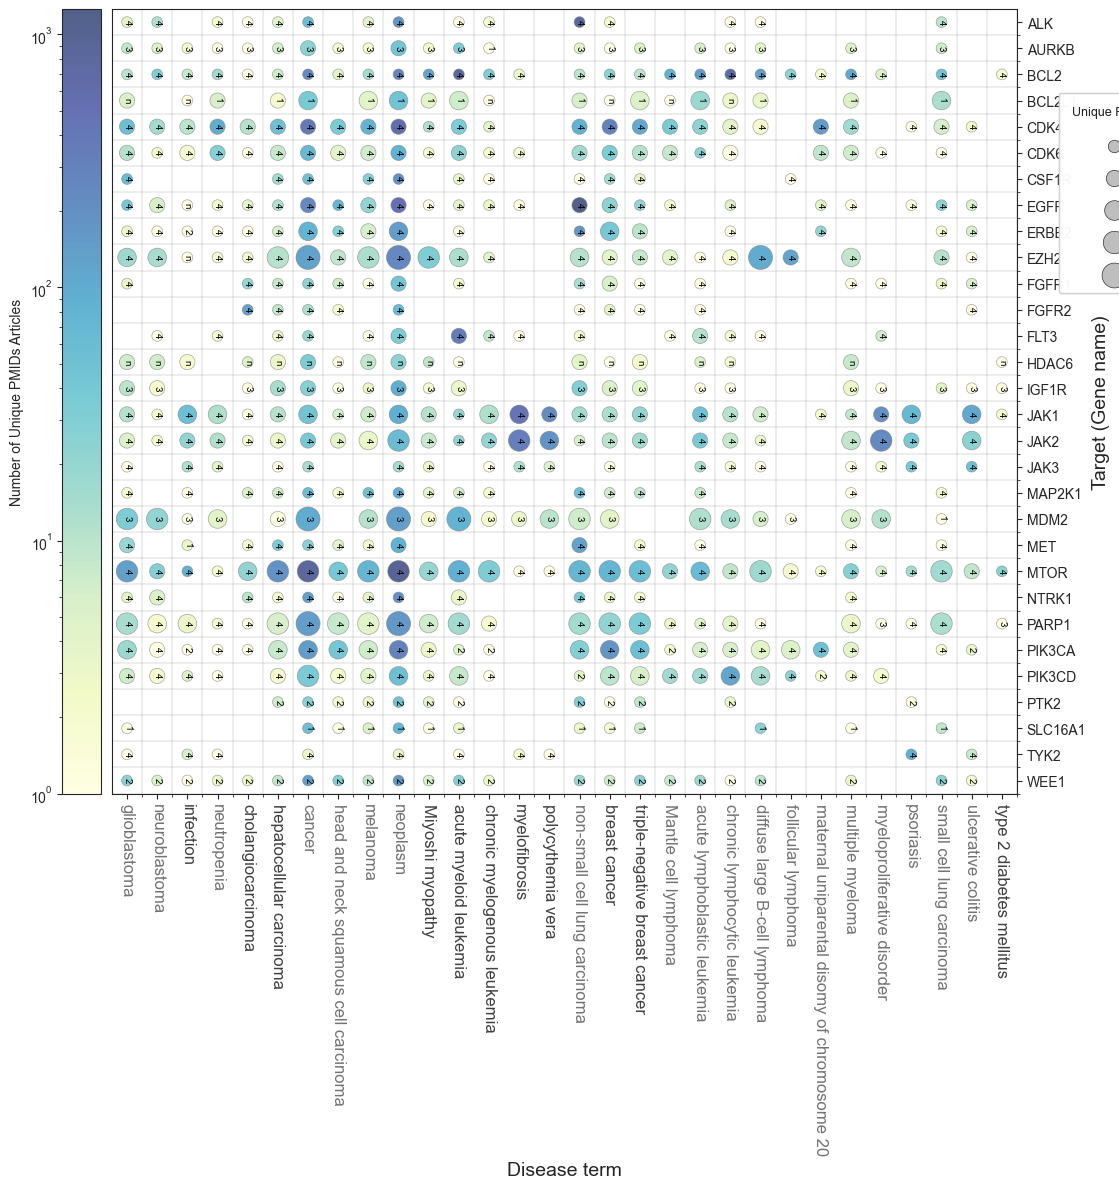

In [32]:
subs = ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.str.startswith(('EFO', 'MONDO'), na=False)]
subs['maxPhase'] = pd.to_numeric(subs['maxPhase'], errors='coerce')

# 1. Create small, unique mapping tables
disease_map = subs[['diseaseId', 'name', 'preferredTA']].drop_duplicates(subset=['diseaseId'])
target_map = subs[['targetId', 'gene']].drop_duplicates()

# 2. Aggregate data using only the necessary columns
grouped_data = subs.groupby(['targetId', 'diseaseId']).agg(
    pmid_count=('pmid', 'nunique'),
    probeId_count=('probeId', 'nunique'),
    max_phase=('maxPhase', 'max')  # <-- MODIFIED: Added max_phase aggregation
).reset_index()

# 3. Filter aggregated data to include most frequent targets and most frequent diseases
grouped_data = grouped_data[
    (grouped_data.diseaseId.isin(dis_freq)) & 
    (grouped_data.targetId.isin(tar_freq))
]

### filter for most frequent T-D pairs
#grouped_data = grouped_data[
#    (grouped_data.diseaseId.isin(sample.diseaseId.unique().tolist())) & 
#    (grouped_data.targetId.isin(sample.targetId.unique().tolist()))
#]

# 4. Merge with the small, efficient mapping tables
grouped_data = grouped_data.merge(disease_map, on='diseaseId', how='left')
grouped_data = grouped_data.merge(target_map, on='targetId', how='left')

# 5. Select final columns.
display(grouped_data[['diseaseId','name']].drop_duplicates())
grouped_data = grouped_data[[
    'gene', 'name', 'diseaseId', 'preferredTA', 
    'probeId_count', 'pmid_count', 'max_phase'  # <-- MODIFIED: Kept max_phase
]]
display(grouped_data.head(2))


if grouped_data.empty:
    print("No association data found to plot.")
else:
    # 2. Map IDs to numerical coordinates
    unique_targets = sorted(grouped_data['gene'].unique()) # Y-axis (alphabetical)
    
    # Get unique (diseaseId, disease name, preferredTA) pairs from the final data
    # This represents every unique disease that will be plotted.
    disease_info_table = grouped_data[['diseaseId', 'name', 'preferredTA', ]].drop_duplicates()
    priority_list = ['GO_0008150', 'EFO_0000651', 'EFO_0000618']
    disease_info_table['sort_priority'] = (~disease_info_table['preferredTA'].isin(priority_list)).astype(int)
    
    # Sort by 'preferredTA' first, then 'diseaseName' alphabetically within each TA
    sorted_disease_info = disease_info_table.sort_values(
        by=['sort_priority','preferredTA', 'name']
    ).reset_index(drop=True)
    
    # Create the final list of disease names for the plot axis
    unique_diseases = sorted_disease_info['name'].tolist()
    
    # This will display the exact order of diseases as they will appear
    # on the X-axis, along with their ID and TA.
    print("\n" + "="*40)
    print("X-Axis Disease Sorting Order (for validation)")
    print("="*40)
    display(sorted_disease_info)
    print("\n")

    # Get the unique TA values in the order they appear
    unique_tas = sorted_disease_info['preferredTA'].unique()
    # Define your two alternating colors
    color_2 = '#404040' # lighter blue
    color_1 = '#737373' # Dark blue
    # Create dictionary mapping each TA to one of the two colors based on its order
    # i % 2 == 0 checks if the index is even.
    ta_to_color = {ta: (color_1 if i % 2 == 0 else color_2) for i, ta in enumerate(unique_tas)}
    # This list is in the *exact* same order as your x-axis labels
    label_tas_in_order = sorted_disease_info['preferredTA'].tolist()

    # 4. Create the mapping dictionaries
    target_to_int = {target: i for i, target in enumerate(unique_targets)}
    disease_to_int = {disease: i for i, disease in enumerate(unique_diseases)}

    grouped_data['target_int'] = grouped_data['gene'].map(target_to_int)
    grouped_data['disease_int'] = grouped_data['name'].map(disease_to_int)

    # --- NEW: Create the text labels from the max_phase column ---
    # This maps NaN (null) to 'n' and numeric values (like 4.0) to integer strings (like '4')
    grouped_data['phase_label'] = grouped_data['max_phase'].apply(
        lambda x: 'n' if pd.isna(x) else str(int(x))
    )
    # --- End of new code ---

    # 3. Prepare data for scatter plot 
    x_coords = grouped_data['disease_int'] # Bubbles centered at integers (0, 1, ...)
    y_coords = grouped_data['target_int'] # Bubbles centered at integers (0, 1, ...)
    bubble_sizes_raw = grouped_data['probeId_count']
    bubble_colors = grouped_data['pmid_count']

    # Bubble Size Scaling
    min_size = 20
    scale_factor = 300
    scaled_sizes = (bubble_sizes_raw / bubble_sizes_raw.max()) * scale_factor

    # Figure Size 
    fig_width = 12
    fig_height = 12
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Color normalization (same as before)
    min_color_val = bubble_colors[bubble_colors > 0].min() if (bubble_colors > 0).any() else 1
    norm = LogNorm(vmin=min_color_val, vmax=bubble_colors.max()) if bubble_colors.max() > 0 else None

    # 6. Create the scatter plot (remove zorder)
    scatter = ax.scatter(
        x=x_coords,
        y=y_coords,
        s=scaled_sizes,
        c=bubble_colors,
        cmap='YlGnBu',
        norm=norm,
        alpha=0.7,
        edgecolors='grey',
        linewidth=0.5
        # No zorder needed here
    )

    # Add clinical phase text inside bubbles  
    for index, row in grouped_data.iterrows():
        ax.text(
        x=row['disease_int'],  
        y=row['target_int'],
            s=str(row['phase_label']).strip(), # <--- Good practice to strip whitespace just in case
            ha='center',
            va='center_baseline',
            fontsize=7,
            color='black',
            fontweight='normal',
            rotation=-90
        )

    # Set MAJOR ticks at integer positions (where labels should appear)
    ax.set_xticks(np.arange(len(unique_diseases)))
    ax.set_xticklabels(unique_diseases, rotation=-90, fontsize=12) # Keep labels at integers
    ax.grid(False, which='major')
    # Get the list of tick label objects
    xtick_labels = ax.get_xticklabels()
    # Loop through the labels and apply the correct color
    # We check the length to avoid errors if something went wrong
    if len(xtick_labels) == len(label_tas_in_order):
        for i, label in enumerate(xtick_labels):
            # Get the preferredTA for this specific label
            ta = label_tas_in_order[i]
            # Get the corresponding color from our map
            color = ta_to_color[ta]
            # Set the label's color
            label.set_color(color)
    else:
        print("Warning: Mismatch between label count and TA data. Colors not applied.")
    ax.grid(False, which='major')

    ax.set_yticks(np.arange(len(unique_targets)))
    # Apply y-label skipping if desired (using major ticks)
    max_labels_y = 50
    ytick_skip = max(1, len(unique_targets) // max_labels_y)
    ax.set_yticklabels(unique_targets[::ytick_skip], fontsize=10)
    # If showing all y-labels: ax.set_yticklabels(unique_targets, fontsize=7)
    # Make sure the corresponding ax.set_yticks reflects the skipping:
    ax.set_yticks(np.arange(len(unique_targets))[::ytick_skip]) # Only set ticks where labels are shown

    # Set MINOR ticks at the halfway points (.5 positions)
    ax.xaxis.set_minor_locator(FixedLocator(np.arange(len(unique_diseases)) + 0.5))
    ax.yaxis.set_minor_locator(FixedLocator(np.arange(len(unique_targets)) + 0.5))

    # Draw the grid using MINOR ticks
    ax.grid(True, which='minor', linestyle='-', linewidth=0.3, color='darkgrey')

    # Ensure grid is drawn BEHIND scatter points ---
    ax.set_axisbelow(True)

    # Set axis limits to align with the minor grid lines
    ax.set_xlim(-0.5, len(unique_diseases) - 0.5)
    ax.set_ylim(-0.5, len(unique_targets) - 0.5)

    # Invert y-axis
    ax.invert_yaxis()

    # Labels and Title 
    ax.set_xlabel('Disease term', fontsize=14)
    ax.set_ylabel('Target (Gene name)', fontsize=14)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

    # Color Bar 
    cbar = fig.colorbar(scatter, ax=ax, label='Number of Unique PMIDs Articles', location='left', pad=0.01)

    # Get unique positive probe counts from the actual data
    # bubble_sizes_raw is grouped_data['probeId_count']
    unique_positive_counts = np.unique(bubble_sizes_raw[bubble_sizes_raw > 0].astype(int))

    if len(unique_positive_counts) == 0:
        legend_probe_counts = np.array([])  # No data for legend
    elif len(unique_positive_counts) <= 5:
        # If 5 or fewer unique positive counts, use all of them for the legend
        legend_probe_counts = unique_positive_counts
    else:
        # If more than 5 unique positive counts, pick up to 5 representative values using linspace
        min_val = unique_positive_counts.min()
        max_val = unique_positive_counts.max()
        # Generate 5 values, including min and max, then ensure they are unique integers
        legend_probe_counts = np.unique(np.linspace(min_val, max_val, num=5).astype(int))

    legend_handles = []
    legend_labels = []

    # Determine the overall maximum raw size for consistent scaling in the legend
    # This should match how 'scaled_sizes' for the main plot was determined
    max_raw_overall_for_scaling = bubble_sizes_raw.max() if not bubble_sizes_raw.empty and bubble_sizes_raw.max() > 0 else 0

    if len(legend_probe_counts) > 0:
        for count_val in legend_probe_counts:
            # Apply the same scaling logic as used for the main plot's bubbles:
            # scaled_sizes = min_size + (bubble_sizes_raw / bubble_sizes_raw.max()) * scale_factor if bubble_sizes_raw.max() > 0 else min_size
            if max_raw_overall_for_scaling > 0:
                scaled_size_legend = min_size + (count_val / max_raw_overall_for_scaling) * scale_factor
            else:
                # Fallback if no positive max_raw_overall (e.g. all counts are 0 or data is empty)
                # This case implies all bubbles would be min_size.
                # If count_val itself can be 0 and min_size is for positive counts, adjust as needed.
                scaled_size_legend = min_size

            legend_handles.append(plt.scatter([], [], s=scaled_size_legend, c='darkgrey', alpha=0.7, edgecolors='black', linewidth=0.5))
            legend_labels.append(f'{count_val}') # Label is the raw probeId_count

        if legend_handles: # Ensure there's something to add to the legend
            size_legend = ax.legend(
                handles=legend_handles, labels=legend_labels, title='Unique Probe IDs',
                loc='upper left', bbox_to_anchor=(1.04, 0.9), # Your existing legend position
                labelspacing=2.0, borderpad=1.2, frameon=True, fontsize=8, title_fontsize=9 # Your existing legend styling
            )
            ax.add_artist(size_legend) # Add this legend to the plot

    # Layout adjustment
    plt.tight_layout()#rect=[0.03, 0.10, 0.90, 0.95])
    #plt.savefig("figs/ner_probes_heatmap_zoom.png", dpi=400)
    plt.savefig("figs/ner_probes_heatmap_zoom.svg", dpi=400)
    plt.show()


### Heatmap zoom in to most novel/interesting targets/diseases pairs
The heatmap shows target and disease where:
* the first chemical probe literature evidence for the pair was reported within the last 5 years
* at least one of the dots (evidence links) has 2 or more chemical probes reported.
* only dots (links) with 15 or less articles found
* no clinical trial reported for the pair (max_phase < -1)

In [ ]:
## Disease ids that have been curated and are wrong. They are to be excluded form the plot but kept in the main dataset
bad_ner_ids = pd.read_csv('validation/negatives.csv', sep=',')['diseaseId'].tolist()
nondisease_ids = pd.read_csv('validation/nondisease.csv', sep=',')['diseaseId'].tolist()


X-Axis Disease Sorting Order (for validation)


,diseaseId,name,preferredTA
0,EFO_0002614,insulin resistance,EFO_0000651
1,EFO_0003907,deep vein thrombosis,EFO_0000651
2,EFO_0009870,bone metastasis,GO_0008150
3,MONDO_0000328,hyperphosphatemia,OTAR_0000020
4,MONDO_0001336,familial hyperlipidemia,OTAR_0000020
...,...,...,...
96,MONDO_0005149,pulmonary hypertension,EFO_0000319
97,EFO_0000612,myocardial infarction,EFO_0000319
98,EFO_0001645,coronary artery disease,EFO_0000319
99,EFO_0009492,cardiac arrest,EFO_0000319


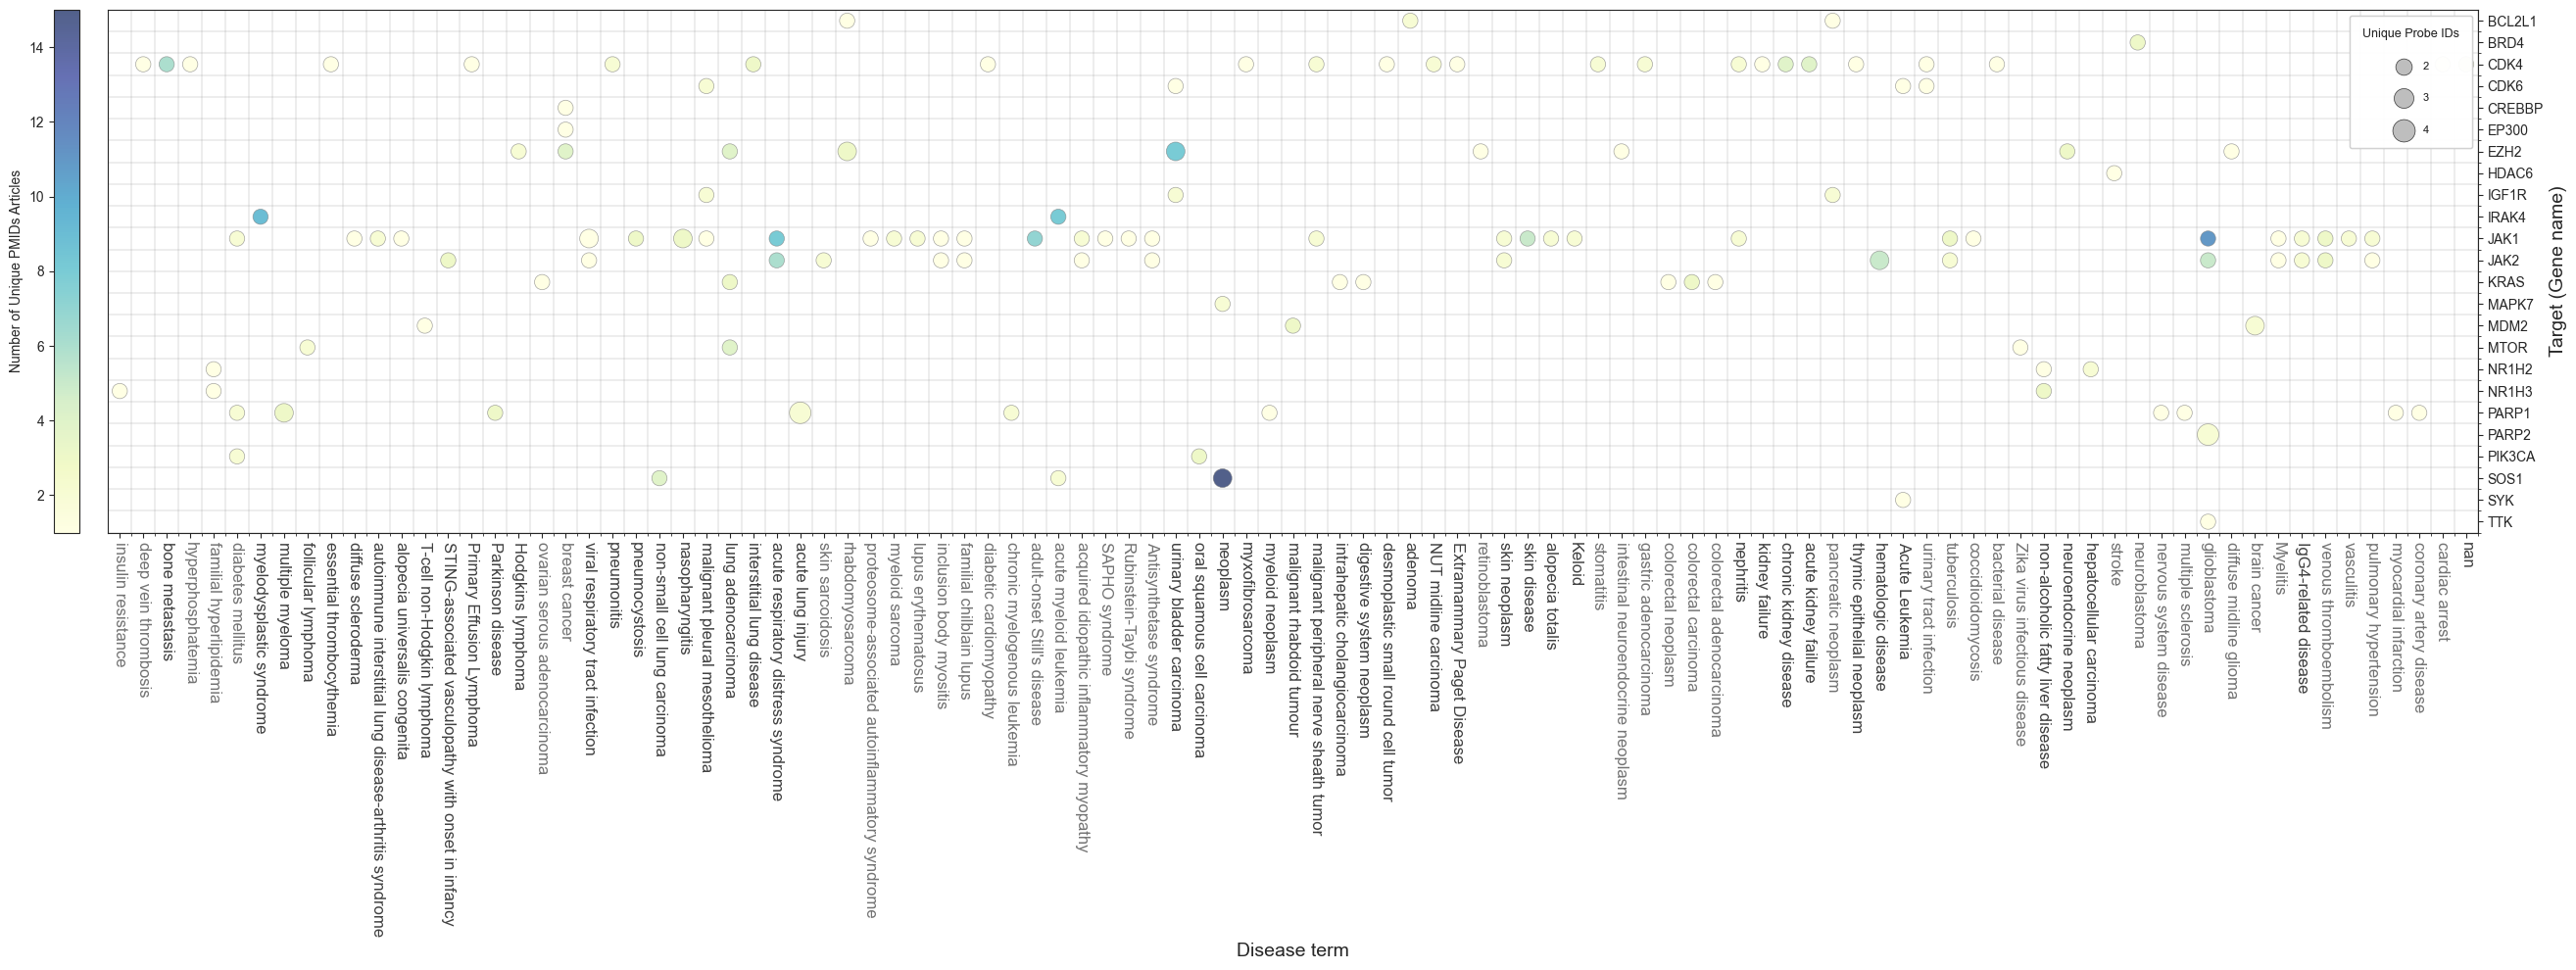

In [173]:
subs3 = ner_triplets_ptpairs[ner_triplets_ptpairs.diseaseId.str.startswith(('EFO', 'MONDO'), na=False)]
subs3 = subs3[(~subs3['diseaseId'].isin(nondisease_ids+bad_ner_ids)) & (subs3['preferredTA'] != 'EFO_0001444')]

# 0. Create mask for target-disease pairs with first evidence in last 5 years
subs3['date'] = pd.to_datetime(subs3['date']) 
start_date = pd.to_datetime('2020-01-01')
end_date = pd.to_datetime('2025-12-31') 
group_min_date = subs3.groupby(['diseaseId', 'targetId'])['date'].transform('min') 
group_max_date = subs3.groupby(['diseaseId', 'targetId'])['date'].transform('max') 
datemask = (group_min_date >= start_date) & (group_max_date <= end_date)
subs3_fi = subs3[datemask].copy()

# 1. Create small, unique mapping tables
disease_map = subs3_fi[['diseaseId', 'name', 'preferredTA']].drop_duplicates(subset=['diseaseId'])
target_map = subs3_fi[['targetId', 'gene']].drop_duplicates()

# 2. Aggregate data using only the necessary columns
subs3_fi['phase'] = pd.to_numeric(subs3_fi['phase'], errors='coerce')
grouped_data = subs3_fi.groupby(['targetId', 'diseaseId']).agg(
    pmid_count=('pmid', 'nunique'),
    probeId_count=('probeId', 'nunique'),
    max_phase=('phase', 'max')
).reset_index()

# 3. Subset aggregated data to most novel targets and most novel diseases
strict=True
if strict:
    #Filter aggregated data to only novel targets and diseases pairs. (The two steps filter ensures adding all bubles for the pair and not just the one with 2 chemical probes or more)
    grouped_data = grouped_data[
        (grouped_data['probeId_count'] > 1) & 
        (grouped_data['pmid_count'] > 0) & (grouped_data['pmid_count'] < 21) &
        ((grouped_data['max_phase'] < -1) | (grouped_data['max_phase'].isna())) # -1 are drugs that don't have assigned level, but drugs anyways
        ] 
    fig_width = 30
    fig_height = 10
else:
    #Filter aggregated data to only novel targets and diseases pairs. (The two steps filter ensures adding all bubles for the pair and not just the one with 2 chemical probes or more)
    grouped_data = grouped_data[
        (grouped_data['probeId_count'] == 0) & 
        (grouped_data['pmid_count'] > 1) & (grouped_data['pmid_count'] < 90) &
        ((grouped_data['max_phase'] < -1) | (grouped_data['max_phase'].isna())) # -1 are drugs that don't have assigned level, but drugs anyways
        ] 
    fig_width = 30
    fig_height = 15

# 4. Merge with the small, efficient mapping tables
grouped_data = grouped_data.merge(disease_map, on='diseaseId', how='left')
grouped_data = grouped_data.merge(target_map, on='targetId', how='left')

# 5. Select final columns. 
#display(grouped_data[['diseaseId','diseaseName']].drop_duplicates())
grouped_data = grouped_data[['gene', 'name', 'diseaseId', 'preferredTA', 'probeId_count', 'pmid_count', 'max_phase']]

if grouped_data.empty:
    print("No association data found to plot.")
else:
    # 2. Map IDs to numerical coordinates
    unique_targets = sorted(grouped_data['gene'].unique()) # Y-axis (alphabetical)
    
    # Get unique (diseaseId, disease name, preferredTA) pairs from the final data
    # This represents every unique disease that will be plotted.
    disease_info_table = grouped_data[['diseaseId', 'name', 'preferredTA', ]].drop_duplicates()
    
    # Sort by 'preferredTA' first, then 'diseaseName' alphabetically within each TA
    #sorted_disease_info = disease_info_table.sort_values(
    #    by=['preferredTA', 'name'],
    #    ascending=[False, False]
    #).reset_index(drop=True)

    # Define the preferredTA IDs to move to the left of the plot
    tas_to_move_left = [
        'EFO_0000651',  
        'EFO_0001444',   
        'GO_0008150'
    ]

    # Separate your data into two DataFrames
    special_labels_df = disease_info_table[disease_info_table['preferredTA'].isin(tas_to_move_left)]
    normal_labels_df = disease_info_table[~disease_info_table['preferredTA'].isin(tas_to_move_left)]
    # Sort special TA
    special_labels_sorted = special_labels_df.sort_values(
        by=['preferredTA', 'name'],
        ascending=[True, False]
    )
    #Sort normal TA
    normal_labels_sorted = normal_labels_df.sort_values(
        by=['preferredTA', 'name'],
        ascending=[False, False]
    )
    #Stack them back together, with the special groups first
    sorted_disease_info = pd.concat([special_labels_sorted, normal_labels_sorted]).reset_index(drop=True)
    
    # Create the final list of disease names for the plot axis
    unique_diseases = sorted_disease_info['name'].tolist()
    
    # This will display the exact order of diseases as they will appear
    # on the X-axis, along with their ID and TA.
    print("\n" + "="*40)
    print("X-Axis Disease Sorting Order (for validation)")
    print("="*40)
    display(sorted_disease_info)
    print("\n")

    # Get the unique TA values in the order they appear
    unique_tas = sorted_disease_info['preferredTA'].unique()
    # Define your two alternating colors
    color_2 = '#404040' # lighter blue
    color_1 = '#737373' # Dark blue
    # Create dictionary mapping each TA to one of the two colors based on its order
    # i % 2 == 0 checks if the index is even.
    ta_to_color = {ta: (color_1 if i % 2 == 0 else color_2) for i, ta in enumerate(unique_tas)}
    # This list is in the *exact* same order as your x-axis labels
    label_tas_in_order = sorted_disease_info['preferredTA'].tolist()

    # 4. Create the mapping dictionaries
    target_to_int = {target: i for i, target in enumerate(unique_targets)}
    disease_to_int = {disease: i for i, disease in enumerate(unique_diseases)}

    grouped_data['target_int'] = grouped_data['gene'].map(target_to_int)
    grouped_data['disease_int'] = grouped_data['name'].map(disease_to_int)

    # 3. Prepare data for scatter plot 
    x_coords = grouped_data['disease_int'] # Bubbles centered at integers (0, 1, ...)
    y_coords = grouped_data['target_int'] # Bubbles centered at integers (0, 1, ...)
    bubble_sizes_raw = grouped_data['probeId_count']
    bubble_colors = grouped_data['pmid_count']

    # 4. Bubble Size Scaling
    min_size = 20
    scale_factor = 250
    scaled_sizes = (bubble_sizes_raw / bubble_sizes_raw.max()) * scale_factor

    # 5. Figure Size 
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # 6. Color normalization (now Linear)
    # By setting norm=None, matplotlib will default to a linear scale
    norm = None

    # 7. Create the scatter plot (remove zorder)
    scatter = ax.scatter(
        x=x_coords,
        y=y_coords,
        s=scaled_sizes,
        c=bubble_colors,
        cmap='YlGnBu',
        norm=norm,
        alpha=0.7,
        edgecolors='grey',
        linewidth=0.5
        # No zorder needed here
    )
        
    # 8. Set MAJOR ticks at integer positions (where labels should appear)
    ax.set_xticks(np.arange(len(unique_diseases)))
    ax.set_xticklabels(unique_diseases, rotation=-90, fontsize=12) # Keep labels at integers
    # Get the list of tick label objects
    xtick_labels = ax.get_xticklabels()
    # Loop through the labels and apply the correct color
    # We check the length to avoid errors if something went wrong
    if len(xtick_labels) == len(label_tas_in_order):
        for i, label in enumerate(xtick_labels):
            # Get the preferredTA for this specific label
            ta = label_tas_in_order[i]
            # Get the corresponding color from our map
            color = ta_to_color[ta]
            # Set the label's color
            label.set_color(color)
    else:
        print("Warning: Mismatch between label count and TA data. Colors not applied.")
    ax.grid(False, which='major')

    ax.set_yticks(np.arange(len(unique_targets)))
    # Apply y-label skipping if desired (using major ticks)
    max_labels_y = 50
    ytick_skip = max(1, len(unique_targets) // max_labels_y)
    ax.set_yticklabels(unique_targets[::ytick_skip], fontsize=10)
    # If showing all y-labels: ax.set_yticklabels(unique_targets, fontsize=7)
    # Make sure the corresponding ax.set_yticks reflects the skipping:
    ax.set_yticks(np.arange(len(unique_targets))[::ytick_skip]) # Only set ticks where labels are shown

    # 9. Set MINOR ticks at the halfway points (.5 positions)
    ax.xaxis.set_minor_locator(FixedLocator(np.arange(len(unique_diseases)) + 0.5))
    ax.yaxis.set_minor_locator(FixedLocator(np.arange(len(unique_targets)) + 0.5))

    # Draw the grid using MINOR ticks
    ax.grid(True, which='minor', linestyle='-', linewidth=0.3, color='darkgrey')

    # Ensure grid is drawn BEHIND scatter points
    ax.set_axisbelow(True)

    # Set axis limits to align with the minor grid lines
    ax.set_xlim(-0.5, len(unique_diseases) - 0.5)
    ax.set_ylim(-0.5, len(unique_targets) - 0.5)

    # 10. Invert y-axis
    ax.invert_yaxis()

    # 11. Labels and Title 
    ax.set_xlabel('Disease term', fontsize=14)
    ax.set_ylabel('Target (Gene name)', fontsize=14)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

    # Color Bar 
    cbar = fig.colorbar(scatter, ax=ax, label='Number of Unique PMIDs Articles', location='left', pad=0.01)

    # Get unique positive probe counts from the actual data
    # bubble_sizes_raw is grouped_data['probeId_count']
    unique_positive_counts = np.unique(bubble_sizes_raw[bubble_sizes_raw > 0].astype(int))

    if len(unique_positive_counts) == 0:
        legend_probe_counts = np.array([])  # No data for legend
    elif len(unique_positive_counts) <= 5:
        # If 5 or fewer unique positive counts, use all of them for the legend
        legend_probe_counts = unique_positive_counts
    else:
        # If more than 5 unique positive counts, pick up to 5 representative values using linspace
        min_val = unique_positive_counts.min()
        max_val = unique_positive_counts.max()
        # Generate 5 values, including min and max, then ensure they are unique integers
        legend_probe_counts = np.unique(np.linspace(min_val, max_val, num=5).astype(int))

    legend_handles = []
    legend_labels = []

    # Determine the overall maximum raw size for consistent scaling in the legend
    # This should match how 'scaled_sizes' for the main plot was determined
    max_raw_overall_for_scaling = bubble_sizes_raw.max() if not bubble_sizes_raw.empty and bubble_sizes_raw.max() > 0 else 0
    if len(legend_probe_counts) > 0:
        for count_val in legend_probe_counts:
            # Apply the same scaling logic as used for the main plot's bubbles
            if max_raw_overall_for_scaling > 0:
                scaled_size_legend = min_size + (count_val / max_raw_overall_for_scaling) * scale_factor
            else:
                # Fallback if no positive max_raw_overall (e.g. all counts are 0 or data is empty)
                # This case implies all bubbles would be min_size.
                # If count_val itself can be 0 and min_size is for positive counts, adjust as needed.
                scaled_size_legend = min_size
            legend_handles.append(plt.scatter([], [], s=scaled_size_legend, c='darkgrey', alpha=0.7, edgecolors='black', linewidth=0.5))
            legend_labels.append(f'{count_val}') # Label is the raw probeId_count
        if legend_handles: # Ensure there's something to add to the legend
            size_legend = ax.legend(
                handles=legend_handles, labels=legend_labels, title='Unique Probe IDs',
                loc='upper right', bbox_to_anchor=(1, 1), # Your existing legend position
                labelspacing=2.0, borderpad=1.2, frameon=True, fontsize=8, title_fontsize=9 # Your existing legend styling
            )
            ax.add_artist(size_legend) # Add this legend to the plot

    # Layout adjustment
    plt.tight_layout()
    #plt.savefig("figs/ner_probes_heatmap_zoom_5y_strong_nc.png", dpi=400)
    plt.savefig("figs/ner_probes_heatmap_zoom_5y_strict.svg", dpi=400)
    plt.show()

In [164]:
### CHECKING EXAMPLEs
ex = subs3[(subs3.diseaseId == 'MONDO_0024352') & (subs3.gene == 'JAK1')][['pmid','section', 'sentence', 'probe', 'phase']] # & (subs3.sentence.str.contains('MBC'))
ex

,pmid,section,sentence,probe,phase
68912,33872590,other,"Despite this challenge, a small number of JAK1-specific inhibitors, including filgotinib—which displays a 30-times greater selectivity for JAK1 than JAK2,43 and is orally administered—and upadacit...",FILGOTINIB,NaN
68913,33872590,other,"Despite this challenge, a small number of JAK1-specific inhibitors, including filgotinib—which displays a 30-times greater selectivity for JAK1 than JAK2,43 and is orally administered—and upadacit...",tofacitinib,NaN
68914,33872590,other,"Despite this challenge, a small number of JAK1-specific inhibitors, including filgotinib—which displays a 30-times greater selectivity for JAK1 than JAK2,43 and is orally administered—and upadacit...",tofacitinib,NaN
68915,33872590,other,"Despite this challenge, a small number of JAK1-specific inhibitors, including filgotinib—which displays a 30-times greater selectivity for JAK1 than JAK2,43 and is orally administered—and upadacit...",FILGOTINIB,NaN
68916,33872590,other,"Despite this challenge, a small number of JAK1-specific inhibitors, including filgotinib—which displays a 30-times greater selectivity for JAK1 than JAK2,43 and is orally administered—and upadacit...",RUXOLITINIB,NaN
68917,33872590,other,"Despite this challenge, a small number of JAK1-specific inhibitors, including filgotinib—which displays a 30-times greater selectivity for JAK1 than JAK2,43 and is orally administered—and upadacit...",RUXOLITINIB,NaN
589869,33872590,other,"Despite this challenge, a small number of JAK1-specific inhibitors, including filgotinib—which displays a 30-times greater selectivity for JAK1 than JAK2,43 and is orally administered—and upadacit...",FILGOTINIB,NaN
589870,33872590,other,"Despite this challenge, a small number of JAK1-specific inhibitors, including filgotinib—which displays a 30-times greater selectivity for JAK1 than JAK2,43 and is orally administered—and upadacit...",tofacitinib,NaN
589871,33872590,other,"Despite this challenge, a small number of JAK1-specific inhibitors, including filgotinib—which displays a 30-times greater selectivity for JAK1 than JAK2,43 and is orally administered—and upadacit...",tofacitinib,NaN
589872,33872590,other,"Despite this challenge, a small number of JAK1-specific inhibitors, including filgotinib—which displays a 30-times greater selectivity for JAK1 than JAK2,43 and is orally administered—and upadacit...",FILGOTINIB,NaN


In [60]:
ner_triplets_ptpairs.maxPhase.unique()

array([4, None, 2, 3, 1], dtype=object)

### OT evidence for target-diseases found

In [ ]:
# plotting eevidence general
df2 = ner_triplets_ptpairs.copy()

# Combine 'TARGET' and 'DISEASE' columns into 'TARGET-DISEASE'
df2['target-disease'] = df2['targetId'] + '-' + df2['diseaseId']
print(df2['target-disease'].nunique())

# Get unique target-disease pairs for each category with the specified priority
other_pairs = set(df2[~df2['datatypeId'].isnull() & (df2['datatypeId'] != 'literature')]['target-disease'].unique())
lit_pairs = set(df2[df2['datatypeId'] == 'literature']['target-disease'].unique()) - other_pairs
none_pairs = set(df2[df2['datatypeId'].isnull()]['target-disease'].unique()) - other_pairs - lit_pairs
ecounts= [len(other_pairs), len(lit_pairs), len(none_pairs)]
evidence = ['Other evidence', 'Literature', 'No evidence']

# Define the colors to use
colors = ['#084594', '#4292c6', '#c6dbef']

# Create the bar plot
plt.bar(evidence, ecounts, color=colors)

# Add value labels on top of each bar
for i in range(len(evidence)):
    plt.text(i, ecounts[i], ecounts[i], ha='center', va='bottom')

# Add labels and title
plt.xlabel("Evidence type")
plt.ylabel("target-disease pairs")

plt.savefig(f'figs/evidence.png', dpi=600)  # Uncomment to save figures
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# plotting eevidence general
df = ner_triplets_ptpairs.copy()

# Combine 'TARGET' and 'DISEASE' columns into 'TARGET-DISEASE'
df['target-disease'] = df['targetId'] + '-' + df['diseaseId']
print(df['target-disease'].nunique())
display(df.datatypeId.unique())

ranked_categories = [
    "genetic_association",
    "somatic_mutation",
    "known_drug",
    "affected_pathway",
    "rna_expression",
    "animal_model",
    "literature",
]

counts = {}
remaining_pairs = set(df['target-disease'].unique()) # Use a set for faster removal.

for category in ranked_categories:
    category_df = df[df.datatypeId == category]
    valid_pairs = set(category_df['target-disease'].unique()) & remaining_pairs # intersection of the pairs in the category and remaining pairs.
    counts[category] = len(valid_pairs)
    remaining_pairs -= valid_pairs # Remove already counted pairs.

counts['no_evidence'] = len(remaining_pairs) # remaining pairs not in any category.

categories = list(counts.keys())
values = list(counts.values())
print(values)

# Create the barplot
plt.figure(figsize=(8, 6))
sns.barplot(x=categories, y=values, palette='Blues_r')
plt.xlabel("Evidence type", fontsize=14)
plt.ylabel("Target-Disease Pairs", fontsize=14)
plt.xticks(rotation=50, ha="right", fontsize=12)
plt.yticks(fontsize=12)

# Add value labels on top of each bar
for i in range(len(ranked_categories)+1):
    plt.text(i, values[i], f"{(values[i]*100)/sum(values):.1f}%", ha='center', va='bottom', fontsize=8)


# Set y-axis to log scale
plt.gca().set_facecolor('white')

# --- Ensure all four spines are visible to form a box ---
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.tight_layout()
plt.savefig(f'figs/evidence_datatype_ranking.svg', dpi=600)  # Uncomment to save figures
plt.savefig(f'figs/evidence_datatype_ranking.png', dpi=600)  # Uncomment to save figures
plt.show()

### Evidence by max phase

In [ ]:

df.groupby('maxPhase')['target-disease'].nunique()

In [ ]:
# Group by diseaseId, targetId, and maxphase, then count unique PMIDs
dfcopy2 = ner_triplets_ptpairs.copy()
dfcopy2['maxPhase'] = dfcopy2.maxPhase.fillna(int(0))
display(dfcopy2.maxPhase.unique())

grouped_data = dfcopy2.groupby(['diseaseId', 'targetId', 'maxPhase'])['pmid'].nunique().reset_index()
grouped_data['maxPhase'] = pd.Categorical(grouped_data['maxPhase'], categories=[0, 1,2,3,4], ordered=True)

display(grouped_data.head())

# Create a list to store PMID counts for each maxphase
data_to_plot = []
max_phases = [0, 1, 2, 3, 4]
for phase in max_phases:
    data_to_plot.append(grouped_data[grouped_data['maxPhase'] == phase]['pmid'].values)

#display(data_to_plot)

# Create the boxplot
plt.figure(figsize=(10, 6)) 
plt.boxplot(data_to_plot, labels=['Preclinical', 1, 2, 3, 4], showfliers=False)
#plt.title('Distribution of Unique PMID Counts by Maxphase (Log Scale)')
plt.xlabel("Max Phase of chemical probe", fontsize=14)
plt.ylabel('Count of Unique Articles (PMIDs) in Log Scale', fontsize=14)

# Add scatter plot points
for i, phase in enumerate(grouped_data['maxPhase'].unique()):
    x = np.random.normal(i + 1, 0.04, size=len(data_to_plot[i]))  # Add jitter
    plt.scatter(x, data_to_plot[i], alpha=0.5, s=10, color='skyblue')  # Adjust alpha and size as needed




# Set y-axis to log scale
plt.yscale('log')

# MAke background white
plt.gca().set_facecolor('white')

# --- Ensure all four spines are visible to form a box ---
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.savefig(f'figs/evidence_maxphase_scatter.svg', dpi=600)  # Uncomment to save figures
plt.savefig(f'figs/evidence_maxphase_scatter.png', dpi=600)  # Uncomment to save figures
plt.show()

##### Finding specific cases to discuss

In [ ]:
### cases
maincopy = ner_triplets_ptpairs.copy()
maincopy['target-disease'] = maincopy['targetId'] + '-' + maincopy['diseaseId']
maincopy['maxPhase'] = maincopy.maxPhase.fillna('NA')

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None) 

In [ ]:

subset = maincopy[(maincopy.datatypeId.isnull()) & (maincopy.maxPhase == 'NA')]
subset.columns
subset[['target-disease','probeId', 'probe']].drop_duplicates()

In [ ]:
#clinical-stage molecules, generating evidence that complements primary indication-focused data
maincopy[maincopy['target-disease'] == 'ENSG00000178999-MONDO_0005178'][['pmid','date','sentence', 'probeId', 'targetId', 'diseaseId', 'gene']]

In [ ]:
#Reporting the risk of diseas einduced by drug
maincopy[maincopy['target-disease'] == 'ENSG00000126266-HP_0002904'][['pmid','date','sentence', 'probeId', 'targetId', 'diseaseId', 'gene']]

In [ ]:
# Referencing to clinical trials
maincopy[maincopy['target-disease'] == 'ENSG00000106462-MONDO_0012825'][['pmid','date','sentence', 'probeId', 'targetId', 'diseaseId', 'gene']]
#maincopy[maincopy['pmid'] == '32967265'][['PMID','date','sentence', 'PROBE', 'TARGET', 'DISEASES']]

In [ ]:
# No evidence and no clinical trials
maincopy[maincopy['target-disease'] == 'ENSG00000131408-HP_0000855'][['pmid','date','sentence', 'probeId', 'targetId', 'diseaseId', 'probe', 'gene']].drop_duplicates()


## Probes articles with dated evidence


In [ ]:
print(len(ner_triplets_ptpairs[['diseaseId', 'targetId']].drop_duplicates()))
ner_triplets_ptpairs['target-disease'] = ner_triplets_ptpairs['targetId'] + '-' + ner_triplets_ptpairs['diseaseId']

In [ ]:
evidence_dated = ner_triplets_ptpairs[ner_triplets_ptpairs[['allcurationYears','allpublicationYears','allstudyYears']].notnull().any(axis=1)]
print(len(evidence_dated[['diseaseId', 'targetId']].drop_duplicates()))

In [ ]:
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import Counter


sets = {
    'curation': set(ner_triplets_ptpairs[ner_triplets_ptpairs.allcurationYears.notnull()]['target-disease'].drop_duplicates()),
    'publication': set(ner_triplets_ptpairs[ner_triplets_ptpairs.allpublicationYears.notnull()]['target-disease'].drop_duplicates()),
    'study': set(ner_triplets_ptpairs[ner_triplets_ptpairs.allstudyYears.notnull()]['target-disease'].drop_duplicates())
}

set_labels = list(sets.keys())
sets = list(sets.values())

# Create the Venn diagram (unweighted)
v = venn3(
    subsets=(1, 1, 1, 1, 1, 1, 1),  # All subsets the same size
    set_labels=set_labels,
)

# Remove the default labels
for text in v.set_labels:
    text.set_text('')

# Get the positions of the labels
label_positions = [text.get_position() for text in v.set_labels]

# Manually set the labels to the correct position and adjust size
for i, label in enumerate(set_labels):
    plt.text(label_positions[i][0], label_positions[i][1], label, ha='center', va='center', fontsize=12)

# Draw circles with fixed radius for unweighted appearance
circles = venn3_circles(
    subsets=(1, 1, 1, 1, 1, 1, 1),  # All subsets the same size
    linestyle="solid",
    linewidth=1,
)

# --- Color Handling with Blues Colormap ---
# Get the Blues colormap
cmap = cm.get_cmap("Blues")

# Define colors from the colormap for each region
# You can adjust these values (0.3 - 0.9) for different shades
colors = [
    cmap(0.4),  # A only
    cmap(0.5),  # B only
    cmap(0.6),  # A and B
    cmap(0.7),  # C only
    cmap(0.8),  # A and C
    cmap(0.9),  # B and C
    cmap(1.0),  # A, B, and C
]

# Set colors for each region
for i, color in enumerate(colors):
    v.get_patch_by_id("100" if i == 0 else "010" if i == 1 else "110" if i == 2 else "001" if i == 3 else "101" if i == 4 else "011" if i == 5 else "111").set_color(color)
    v.get_patch_by_id("100" if i == 0 else "010" if i == 1 else "110" if i == 2 else "001" if i == 3 else "101" if i == 4 else "011" if i == 5 else "111").set_alpha(0.8) # Add some alpha for visibility

# Set the labels for each region (manually calculate intersections)
v.get_label_by_id("100").set_text(len(sets[0] - sets[1] - sets[2]))  # A only
v.get_label_by_id("010").set_text(len(sets[1] - sets[0] - sets[2]))  # B only
v.get_label_by_id("110").set_text(
    len(sets[0] & sets[1] - sets[2])
)  # A and B
v.get_label_by_id("001").set_text(len(sets[2] - sets[0] - sets[1]))  # C only
v.get_label_by_id("101").set_text(
    len(sets[0] & sets[2] - sets[1])
)  # A and C
v.get_label_by_id("011").set_text(
    len(sets[1] & sets[2] - sets[0])
)  # B and C
v.get_label_by_id("111").set_text(
    len(sets[0] & sets[1] & sets[2])
)  # A, B, and C

plt.savefig(f'figs/supp_dated_evidence.png', dpi=600)  # Uncomment to save figures

# Display the diagram
plt.show()

In [ ]:
evidence_dated = ner_triplets_ptpairs[ner_triplets_ptpairs[['allcurationYears','allstudyYears', 'allpublicationYears']].notnull().any(axis=1)]
print(evidence_dated['target-disease'].nunique())

In [ ]:
ner_triplets_ptpairs_nl = ner_triplets_ptpairs[ner_triplets_ptpairs.datatypeId != 'literature']
evidence_dated_nl = ner_triplets_ptpairs_nl[ner_triplets_ptpairs_nl[['allcurationYears','allstudyYears', 'allpublicationYears']].notnull().any(axis=1)]
print(evidence_dated_nl['target-disease'].nunique())

In [ ]:
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import Counter


sets = {
    'curation': set(ner_triplets_ptpairs_nl[ner_triplets_ptpairs_nl.allcurationYears.notnull()]['target-disease'].drop_duplicates()),
    'publication': set(ner_triplets_ptpairs_nl[ner_triplets_ptpairs_nl.allpublicationYears.notnull()]['target-disease'].drop_duplicates()),
    'study': set(ner_triplets_ptpairs_nl[ner_triplets_ptpairs_nl.allstudyYears.notnull()]['target-disease'].drop_duplicates())
}

set_labels = list(sets.keys())
sets = list(sets.values())

# Create the Venn diagram (unweighted)
v = venn3(
    subsets=(1, 1, 1, 1, 1, 1, 1),  # All subsets the same size
    set_labels=set_labels,
)

# Remove the default labels
for text in v.set_labels:
    text.set_text('')

# Get the positions of the labels
label_positions = [text.get_position() for text in v.set_labels]

# Manually set the labels to the correct position and adjust size
for i, label in enumerate(set_labels):
    plt.text(label_positions[i][0], label_positions[i][1], label, ha='center', va='center', fontsize=12)

# Draw circles with fixed radius for unweighted appearance
circles = venn3_circles(
    subsets=(1, 1, 1, 1, 1, 1, 1),  # All subsets the same size
    linestyle="solid",
    linewidth=1,
)

# --- Color Handling with Blues Colormap ---
# Get the Blues colormap
cmap = cm.get_cmap("Blues")

# Define colors from the colormap for each region
# You can adjust these values (0.3 - 0.9) for different shades
colors = [
    cmap(0.4),  # A only
    cmap(0.5),  # B only
    cmap(0.6),  # A and B
    cmap(0.7),  # C only
    cmap(0.8),  # A and C
    cmap(0.9),  # B and C
    cmap(1.0),  # A, B, and C
]

# Set colors for each region
for i, color in enumerate(colors):
    v.get_patch_by_id("100" if i == 0 else "010" if i == 1 else "110" if i == 2 else "001" if i == 3 else "101" if i == 4 else "011" if i == 5 else "111").set_color(color)
    v.get_patch_by_id("100" if i == 0 else "010" if i == 1 else "110" if i == 2 else "001" if i == 3 else "101" if i == 4 else "011" if i == 5 else "111").set_alpha(0.8) # Add some alpha for visibility

# Set the labels for each region (manually calculate intersections)
v.get_label_by_id("100").set_text(len(sets[0] - sets[1] - sets[2]))  # A only
v.get_label_by_id("010").set_text(len(sets[1] - sets[0] - sets[2]))  # B only
v.get_label_by_id("110").set_text(
    len(sets[0] & sets[1] - sets[2])
)  # A and B
v.get_label_by_id("001").set_text(len(sets[2] - sets[0] - sets[1]))  # C only
v.get_label_by_id("101").set_text(
    len(sets[0] & sets[2] - sets[1])
)  # A and C
v.get_label_by_id("011").set_text(
    len(sets[1] & sets[2] - sets[0])
)  # B and C
v.get_label_by_id("111").set_text(
    len(sets[0] & sets[1] & sets[2])
)  # A, B, and C

plt.savefig(f'figs/supp_dated_evidence.png', dpi=600)  # Uncomment to save figures

# Display the diagram
plt.show()

In [ ]:
## Find all cases where the probe article was published before the earliest evience in OT
## Find cases where many articles and many probes were found before the evidence
#Only then make the line plot for such cases (no more than 10 good cases)
#should we check the section where sentence was found?

In [ ]:
def min_first_evidence(group):
  """Calculates the minimum firstEvidence, excluding 'literature' datatype."""
  eligible_rows = group[group['datatypeId'] != 'literature']
  if eligible_rows.empty:
    return 0  # Return 0 if no eligible rows
  else:
    return eligible_rows['firstEvidence'].min()

In [ ]:
# Calculting difference in years
evidence_dated_nl['date'] = pd.to_datetime(evidence_dated_nl['date'])

evidence_dated_nl['firstEvidence_study'] = evidence_dated_nl['allstudyYears'].apply(lambda x: min(int(year) for year in x[1:-1].split(', ')) if pd.notnull(x) and x[1:-1].strip() else None)
evidence_dated_nl['firstEvidence_curation'] = evidence_dated_nl['allcurationYears'].apply(lambda x: min(int(year) for year in x[1:-1].split(', ')) if pd.notnull(x) and x[1:-1].strip() else None)
evidence_dated_nl['firstEvidence_pub'] = evidence_dated_nl['allpublicationYears'].apply(lambda x: min(int(year) for year in x[1:-1].split(', ')) if pd.notnull(x) and x[1:-1].strip() else None)

evidence_dated_nl['firstEvidence'] = evidence_dated_nl[['firstEvidence_study', 'firstEvidence_curation', 'firstEvidence_pub']].min(axis=1)
evidence_dated_nl['firstEvidence'] = pd.to_numeric(evidence_dated_nl['firstEvidence'], errors='coerce').fillna(0).astype(int)
#display(evidence_dated)


# Calculate the minimum firstEvidence for each group
#min_evidence = evidence_dated.groupby(['diseaseId', 'targetId']).apply(min_first_evidence)

# Merge the minimum firstEvidence back into the original DataFrame
#evidence_dated_all = evidence_dated.merge(min_evidence.rename('firstEvidenceAll'), left_on=['diseaseId', 'targetId'], right_index=True)
evidence_dated_nl['firstEvidenceAll'] = evidence_dated_nl.groupby(['targetId', 'diseaseId'])['firstEvidence'].transform('min')



In [ ]:
evidence_dated_nl.columns

In [ ]:
#Only cases where probes evidence was before other evidence
subset = evidence_dated_nl[evidence_dated_nl.date.dt.year.astype(int) < evidence_dated_nl.firstEvidenceAll.astype(int)][[ 'pmid', 'date', 'targetId', 'diseaseId', 'probeId', 'gene', 'probe', 'diseaseName', 'inchiKey', 'sentence', 'datasourceId', 'datatypeId', 'firstEvidence', 'firstEvidenceAll']] #, 
display(len(subset[['diseaseId', 'targetId']].drop_duplicates()))
display(len(subset[['diseaseId', 'targetId', 'probeId', 'pmid']].drop_duplicates()))

In [ ]:
#subset = evidence_dated_nl #comment to keep all cases and not just the ones with earlier evidence
# 1. Calculate the difference
subset['diffYears'] = (subset['firstEvidenceAll'] - subset.date.dt.year)
subset = subset[subset.firstEvidence == subset.firstEvidenceAll].drop_duplicates() #To consider only the case with the earliest year (cometime we have multiple evidence type with different years)

# 2. Sort by the 'diff' column in descending order
subset_sorted = subset.sort_values('diffYears', ascending=False)

In [ ]:
#Difference in years for the early evidence with probes
# 1. Calculate the absolute difference
print(subset.diffYears.mean(), subset.diffYears.min(), subset.diffYears.max(), subset.diffYears.mode())

# 2. Calculate how many cases 0-5, 5-10, >10.
msubset = subset_sorted.drop_duplicates(['diseaseId', 'targetId'], keep='first')
print(len(msubset))
print(len(msubset[msubset.diffYears <5]))
print(len(msubset[(msubset.diffYears >4) & (msubset.diffYears <10)]))
print(len(msubset[msubset.diffYears >9]))

In [ ]:
#Subset to print consideirng only the unique pairs
subset_plot = subset_sorted[['gene', 'diseaseName','probe', 'pmid', 'date', 'firstEvidenceAll', 'diffYears']].drop_duplicates(['gene', 'diseaseName'], keep='first')
subset_table = subset_plot.head(30)
subset_table.to_csv('tables/ner_pairs_early_evidence.tsv', sep='\t')
#Difference in years for the early evidence with probes
print(subset_plot.diffYears.mean(), subset_plot.diffYears.min(), subset_plot.diffYears.max(), subset_plot.diffYears.mode())

In [ ]:
categories = subset_plot.datatypeId.unique()

plt.figure(figsize=(10, 6))  

for cat in categories:
    # Use a different variable name here
    data_subset = subset_plot[subset_plot.datatypeId == cat]
    sns.kdeplot(data_subset['diffYears'], label=cat, fill=True) 

plt.xlabel('Difference in years', fontsize=14)
plt.ylabel('Target-disease evidence with probes (%)', fontsize=14)
plt.legend()

plt.savefig(f'figs/early_evidence_density_datatypeId.svg', dpi=600)  # Uncomment to save figures

plt.show()

In [ ]:
categories = subset_plot.datasourceId.unique()

plt.figure(figsize=(10, 6))  

for cat in categories:
    # Use a different variable name here
    data_subset = subset_plot[subset_plot.datasourceId == cat]
    sns.kdeplot(data_subset['diffYears'], label=cat, fill=True) 

plt.xlabel('Difference in years', fontsize=14)
plt.ylabel('Target-disease evidence with probes (%)', fontsize=14)
plt.legend()

plt.savefig(f'figs/early_evidence_density_datasourceId.svg', dpi=600)  # Uncomment to save figures

plt.show()

## Probes from a time perspective: using publication date from P&D

In [ ]:

#Reading probes publication year from Probes&Drugs
probes_pub = pd.read_csv('data/probe_references.csv', sep=',') #From probes&drugs Ctibor

#Merging year of prob to main dataset
ner_triplets_ptpairs = pd.merge(ner_triplets_ptpairs, probes_pub[['STANDARDIZED_INCHIKEY', 'YEAR', 'PUBMED_ID', 'REF_TYPE']],left_on='inchiKey', right_on='STANDARDIZED_INCHIKEY', how='left').drop(columns='STANDARDIZED_INCHIKEY').rename(columns={"YEAR": "probeYear", "PUBMED_ID":"probeYearPubmed", "REF_TYPE":"probeYearType"})
print(len(ner_triplets_ptpairs))


In [ ]:

#Merging year of prob to main dataset
evidence_dated_nl_date = pd.merge(evidence_dated_nl, probes_pub[['STANDARDIZED_INCHIKEY', 'YEAR', 'PUBMED_ID', 'REF_TYPE']],left_on='inchiKey', right_on='STANDARDIZED_INCHIKEY', how='left').drop(columns='STANDARDIZED_INCHIKEY').rename(columns={"YEAR": "probeYear", "PUBMED_ID":"probeYearPubmed", "REF_TYPE":"probeYearType"})
print(len(evidence_dated_nl_date))

In [ ]:

count_pubmeds = ner_triplets_ptpairs.groupby('probeId')[['probeYearPubmed','probeYearType']].nunique().reset_index()
plt.figure(figsize=(10, 6)) # Optional: Adjust figure size
sns.countplot(data=count_pubmeds, x='probeYearPubmed')
plt.xlabel("Number of linked publications")
plt.ylabel("Count of chemical probes")
plt.savefig('figs/supp_linked_publications.png', dpi=400)

In [ ]:

display(ner_triplets_ptpairs.probeId.nunique())

#cases of probe without date provided by probes&drugs
nodates_subset = ner_triplets_ptpairs[ner_triplets_ptpairs.probeYear.isna()]
display(nodates_subset.probe.unique())

#Type of publication
display(ner_triplets_ptpairs[['probeId','probeYearType']].drop_duplicates().probeYearType.value_counts())

direct_probeIds = ner_triplets_ptpairs[ner_triplets_ptpairs['probeYearType'] == 'direct']['probeId'].unique()
activity_based_probeIds = ner_triplets_ptpairs[ner_triplets_ptpairs['probeYearType'] == 'activity-based']['probeId'].unique()
print(len(set(direct_probeIds)))
print(len(set(activity_based_probeIds) - set(direct_probeIds)))

#### Only direct link publications

In [ ]:

# only considering direct publications
date_subset =ner_triplets_ptpairs[ner_triplets_ptpairs.probeYearType == 'direct'] #chnage to dated evidence dataset in case we need the OT dates
print(ner_triplets_ptpairs.probeId.nunique())
print(date_subset.probeId.nunique())
#filter out cases without dates
date_subset = date_subset[~date_subset.probeYear.isna()]
date_subset.probeYear = date_subset.probeYear.astype('int')

In [ ]:

date_subset.date = pd.to_datetime(date_subset.date)

In [ ]:

date_subset.columns

In [ ]:

display(len(date_subset[['targetId','diseaseId','probeId']].drop_duplicates()))
date_subset['triplets'] = date_subset.diseaseId + '-' + date_subset.targetId + '-' + date_subset.probeId
date_subset['year'] = date_subset.date.dt.year.astype(int)


In [ ]:

date_subset.probeId.nunique()

In [ ]:

display(date_subset[['triplets', 'pmid', 'probeYear', 'year', 'probeYearPubmed']].drop_duplicates().head())

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Import ticker module

# --- Assuming date_subset is defined and loaded somewhere above ---
# Example placeholder:
# date_subset = pd.read_csv('your_data.csv')

# Use user's data loading method
df = date_subset[['triplets', 'pmid', 'probeYear', 'year' ,'probeYearPubmed', 'section', 'sentence', 'probeId']].drop_duplicates()

# Ensure years are integers
df['probeYear'] = df['probeYear'].astype(int)
df['year'] = df['year'].astype(int)

print("User DataFrame head:")
print(df.head())
print(f"\nTotal unique rows: {len(df)}")

# --- 2. Calculate Year Difference (Using User's Formula) ---
df['year_diff'] = df['year'] - df['probeYear'] # User's formula
print("\nDataFrame with year_diff:")
print(df.head())

# --- 3. Calculate EXACT COUNT per Year Difference ---
exact_counts = df['year_diff'].value_counts().sort_index()

# --- 4. Reindex to include all integer years in the range ---
if not exact_counts.empty:
    min_diff = df['year_diff'].min()
    max_diff = df['year_diff'].max()
    full_index = range(min_diff, max_diff + 1)
    exact_counts = exact_counts.reindex(full_index, fill_value=0)
    data_max_count = exact_counts.values.max()
else:
    print("\nWarning: No 'year_diff' data to plot.")
    data_max_count = 0
    exact_counts = pd.Series()

print(f"\nMaximum calculated count: {data_max_count}")
print("Count per exact year difference (with gaps filled):")
print(exact_counts.head())


# --- 5. Generate the Plot (Bar Plot with Exact Counts & Fewer Y Ticks) ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plotting Section Changed ---
# Check if there is data to plot
if not exact_counts.empty:
    bar_positions = exact_counts.index
    bar_heights = exact_counts.values
    ax.bar(bar_positions, bar_heights, width=0.8) # User's edgecolor

    ax.set_xlabel("Evidence Publication Year - Chemical Probe Approval Year", fontsize=14) # User's label

    ax.axvline(0, color='#8B0000', linestyle='--', linewidth=2, label='Probe Approval at 0', ymax=0.95) # User's style

    # --- DYNAMIC Y-axis Limits and Ticks (based on COUNT) ---
    if data_max_count > 0:
        # Determine upper limit (same logic as before)
        upper_limit = np.ceil(data_max_count) + 1
        if data_max_count > 50:
             upper_limit = np.ceil(data_max_count / 10) * 10 + 5
        elif data_max_count > 20:
             upper_limit = np.ceil(data_max_count / 5) * 5 + 2
    else:
        upper_limit = 5

    # Set Y limits dynamically
    ax.set_ylim(bottom=0, top=upper_limit)

    # --- Use MaxNLocator for Fewer Y Ticks ---  ## CHANGED ##
    # Remove the manual calculation of tick_step and np.arange
    # ax.set_yticks(np.arange(0, upper_limit + 1, tick_step)) # REMOVED
    # Use MaxNLocator - aims for max 'nbins' ticks, ensures integers
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=6)) # Aim for ~6 ticks
    # --- End of Y Tick Change ---

    # Add text annotation for the vertical line - position based on NEW upper limit
    text_y_pos_final = upper_limit * 0.9
    ax.text(0 + 0.40, text_y_pos_final, "Chemical Probe approval", rotation=90, va='top', color='#8B0000', fontsize=12) # User's text/style
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)

else:
    ax.set_xlabel("Evidence Publication Year - Chemical Probe Approval Year") # User's label
    #ax.set_ylim(bottom=0, top=5)

# Set general plot properties
#ax.set_title("Distribution of time lag between main publication and evidence publication")
ax.set_ylabel('T-D Evidence from Chemical Probes in Literature', fontsize=14) # User's label (updated for count)
ax.grid(axis='y', linestyle='--', alpha=0.7) # User's grid style

# Improve layout and display plot
plt.tight_layout()
plt.savefig(f'figs/probes_evidece_time.png', dpi=600)  # Uncomment to save figures
plt.show()

In [ ]:

#find cases where the evidence was found before the approval of the probe
df[(df.year_diff == 10)].head(20)

In [ ]:

# Count Frequency of Values in the 'probeYear' Column ---
# Get unique probe counts per year
subset = df[['probeId', 'probeYear']].drop_duplicates(subset=['probeId'], keep='first')
year_counts = subset['probeYear'].value_counts()

# Sort by year (index) for plotting
year_counts = year_counts.sort_index()

# Calculate the cumulative sum of frequencies
cumulative_frequencies = year_counts.cumsum() # <-- Added cumulative calculation

# Extract years (x-axis), frequencies (y-axis 1), and cumulative frequencies (y-axis 2)
years = year_counts.index
frequencies = year_counts.values
cumulative_values = cumulative_frequencies.values # <-- Get cumulative values

# --- 3. Create the Line Plot with Dual Y-Axes ---
fig, ax1 = plt.subplots(figsize=(10, 6)) # Create a figure and the primary axes

# Plot frequency per year on the primary y-axis (ax1)
color1 = '#4292c6' # Define color for first axis
ax1.set_xlabel('Year')
ax1.set_ylabel('Frequency per Year (Count)', color=color1, fontsize=14) # Label for primary axis
line1 = ax1.plot(years, frequencies,
                 marker='o',
                 linestyle='-',
                 color=color1,
                 label='Frequency per Year') # Add label for legend
ax1.tick_params(axis='y', labelcolor=color1, labelsize=11)
ax1.grid(True, linestyle='--', alpha=0.7) # Add grid based on primary axis

# Create a secondary y-axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()
color2 = '#08306b' # Define color for second axis
ax2.set_ylabel('Cumulative Count', color=color2, fontsize=14) # Label for secondary axis
# Plot cumulative frequency on the secondary y-axis (ax2)
line2 = ax2.plot(years, cumulative_values,
                 marker='^',       # Different marker
                 linestyle='--',   # Different line style
                 color=color2,
                 label='Cumulative Count') # Add label for legend
ax2.tick_params(axis='y', labelcolor=color2,labelsize=11)


# --- 4. Customize the Plot ---
#plt.title('Probe Approval Frequency and Cumulative Count by Year') # Updated title
ax1.set_xlabel('Year', fontsize=14) # Label for secondary axis
ax1.set_xticks(years)
ax1.tick_params(axis='x', rotation=90, labelsize=11)
# Add a combined legend for both lines
lines = line1 + line2
labels = [l.get_label() for l in lines]
# Place legend (adjust location 'loc' as needed, e.g., 'upper left', 'center left')
ax1.legend(lines, labels, loc='upper left')

# --- 5. Show the Plot ---
fig.tight_layout() # Adjust layout to prevent labels overlapping (use fig.tight_layout with axes objects)
plt.savefig(f'figs/probes_approval.png', dpi=600)  # Uncomment to save figures
plt.show()

# --- Optional: Print the counts ---
print("Year Frequencies:")
print(year_counts)
print("\nCumulative Frequencies:")
print(cumulative_frequencies) # <-- Print cumulative counts too

## Probes from a time perspective: using published date in website


In [ ]:
#Reading probes publication year from Probes&Drugs
probes_date = pd.read_csv('data/probes_HQ_with_dates.tsv', sep='\t')

#Merging year of prob to main dataset
ner_triplets_ptpairs = pd.merge(ner_triplets_ptpairs, probes_date[['INCHI','Earliest_Date']],left_on='inchiKey', right_on='INCHI', how='left').drop(columns='INCHI').rename(columns={"Earliest_Date": "probeYearWs"})
print(len(ner_triplets_ptpairs))



In [ ]:
ner_triplets_ptpairs.head()

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Import ticker module

# --- Assuming date_subset is defined and loaded somewhere above ---
# Example placeholder:
# date_subset = pd.read_csv('your_data.csv')

# Use user's data loading method
date_subset = ner_triplets_ptpairs.copy()
date_subset = date_subset[~date_subset.probeYear.isna()]
date_subset['triplets'] = date_subset.diseaseId + '-' + date_subset.targetId + '-' + date_subset.probeId
date_subset = date_subset[['triplets', 'pmid', 'probeYearWs', 'date', 'section', 'sentence', 'probeId']].drop_duplicates()
date_subset['evidenceYear'] = date_subset['date'].astype(int)
date_subset['probeYearWs'] = date_subset['probeYearWs'].str.split('-').str[0].astype(int)



print("User DataFrame head:")
print(date_subset.head())
print(f"\nTotal unique rows: {len(date_subset)}")

# --- 2. Calculate Year Difference (Using User's Formula) ---
date_date_subset['year_diff'] = date_subset['evidenceYear'] - date_subset['probeYearWs'] # User's formula
print("\nDataFrame with year_diff:")
print(date_subset.head())

# --- 3. Calculate EXACT COUNT per Year Difference ---
exact_counts = date_subset['year_diff'].value_counts().sort_index()

# --- 4. Reindex to include all integer years in the range ---
if not exact_counts.empty:
    min_diff = date_subset['year_diff'].min()
    max_diff = date_subset['year_diff'].max()
    full_index = range(min_diff, max_diff + 1)
    exact_counts = exact_counts.reindex(full_index, fill_value=0)
    data_max_count = exact_counts.values.max()
else:
    print("\nWarning: No 'year_diff' data to plot.")
    data_max_count = 0
    exact_counts = pd.Series()

print(f"\nMaximum calculated count: {data_max_count}")
print("Count per exact year difference (with gaps filled):")
print(exact_counts.head())


# --- 5. Generate the Plot (Bar Plot with Exact Counts & Fewer Y Ticks) ---
fig, ax = plt.subplots(figsize=(12, 6))

# --- Plotting Section Changed ---
# Check if there is data to plot
if not exact_counts.empty:
    bar_positions = exact_counts.index
    bar_heights = exact_counts.values
    ax.bar(bar_positions, bar_heights, width=0.8, edgecolor='black') # User's edgecolor

    ax.set_xlabel("Evidence year - probe's approval year") # User's label

    ax.axvline(0, color='orange', linestyle='--', linewidth=2, label='Probe Approval at 0', ymax=0.95) # User's style

    # --- DYNAMIC Y-axis Limits and Ticks (based on COUNT) ---
    if data_max_count > 0:
        # Determine upper limit (same logic as before)
        upper_limit = np.ceil(data_max_count) + 1
        if data_max_count > 50:
             upper_limit = np.ceil(data_max_count / 10) * 10 + 5
        elif data_max_count > 20:
             upper_limit = np.ceil(data_max_count / 5) * 5 + 2
    else:
        upper_limit = 5

    # Set Y limits dynamically
    ax.set_ylim(bottom=0, top=upper_limit)

    # --- Use MaxNLocator for Fewer Y Ticks ---  ## CHANGED ##
    # Remove the manual calculation of tick_step and np.arange
    # ax.set_yticks(np.arange(0, upper_limit + 1, tick_step)) # REMOVED
    # Use MaxNLocator - aims for max 'nbins' ticks, ensures integers
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=6)) # Aim for ~6 ticks
    # --- End of Y Tick Change ---

    # Add text annotation for the vertical line - position based on NEW upper limit
    text_y_pos_final = upper_limit * 0.9
    ax.text(0 + 0.15, text_y_pos_final, "Probe's approval", rotation=90, va='top', color='orange') # User's text/style

else:
    ax.set_xlabel("Evidence publication year - probe's main publication year") # User's label
    #ax.set_ylim(bottom=0, top=5)

# Set general plot properties
ax.set_title("Distribution of time lag between main publication and evidence publication")
ax.set_ylabel('target-disease evidence from probes in literature') # User's label (updated for count)
ax.grid(axis='y', linestyle='--', alpha=0.7) # User's grid style

# Improve layout and display plot
plt.tight_layout()
plt.savefig(f'figs/probes_evidece_time2.png', dpi=600)  # Uncomment to save figures
plt.show()

### finding cases after date of approval

In [ ]:
#Cases where probe was approved as probe and then first paper for pair
df_merged = date_subset.groupby('triplets').filter(
    lambda group: (group.probeYear.min() < group['year'].min()) and \
                  (group.year.max() < group.firstEvidenceAll.min())
)
df_merged['probeYear_min'] = df_merged.groupby('triplets')['probeYear'].transform('min')
df_merged['articleYear_min'] = df_merged.groupby('triplets')['year'].transform('min')
print(len(df_merged.triplets.unique()))

case1 = df_merged[['diseaseId', 'targetId', 'probeId', 'probeYear_min', 'articleYear_min','firstEvidenceAll', 'triplets']].drop_duplicates()
display(case1)


In [ ]:
# Plot to show timeline
df = case1.copy()
df['probeYear_min'] = pd.to_numeric(df['probeYear_min'])
df['articleYear_min'] = pd.to_numeric(df['articleYear_min'])
df['firstEvidenceAll'] = pd.to_numeric(df['firstEvidenceAll'])

df_sorted = df.sort_values('probeYear_min').reset_index(drop=True)

plt.figure(figsize=(15, len(df_sorted) * 0.4)) # Adjust height based on number of rows

# Define the columns containing the years
year_cols = ['probeYear_min', 'articleYear_min', 'firstEvidenceAll']

for index, row in df_sorted.iterrows():
    years = row[year_cols].values
    y_level = index
    y_values = [y_level] * len(years)
    plt.plot(years, y_values, marker='x', linestyle='-', color='skyblue', markerfacecolor='darkblue', markeredgecolor='darkblue')


# --- 3. Customize the plot ---
plt.xlabel("Year")
plt.ylabel("Disease-Target-Probe Triplet") # Or "Item", "Record", etc.
plt.title("Timeline of Target-Disease links from a Probe's perspective")

# Set y-ticks positions to 0, 1, 2... and labels to the corresponding 'triplets' values
plt.yticks(range(len(df_sorted)), df_sorted['triplets'])
# Adjust font size if labels are too long or overlap
plt.yticks(range(len(df_sorted)), df_sorted['triplets'], fontsize=10)

plt.grid(axis='x', linestyle='-', alpha=0.6) # Add vertical grid lines for years
plt.tight_layout() # Adjust layout to prevent labels overlapping

plt.savefig(f'figs/timeline_case1.png', dpi=600)  # Uncomment to save figures

plt.show()

In [ ]:
filter_keys = grouped[['diseaseId', 'targetId', 'probeId']].drop_duplicates()

# Perform an inner merge. This keeps only rows from df1 that have a match
# in filter_keys based on the key_columns.
newdf = pd.merge(date_subset, filter_keys, on=['diseaseId', 'targetId', 'probeId'], how='inner')


In [ ]:
#Example
test = evidence_dated_nl_date[(evidence_dated_nl_date.probeId == 'CHEMBL472') & (evidence_dated_nl_date.diseaseId == 'EFO_1001511')]
test

In [ ]:
#Cases where probe was approved after first paper for pair
df_merged = date_subset.groupby('triplets').filter(
    lambda group: (group.probeYear.min() > group['year'].max()) 
)
df_merged['probeYear_min'] = df_merged.groupby('triplets')['probeYear'].transform('min')
df_merged['articleYear_min'] = df_merged.groupby('triplets')['year'].transform('min')
print(len(df_merged.triplets.unique()))

case2 = df_merged[['diseaseId', 'targetId', 'probeId', 'probeYear_min', 'articleYear_min','firstEvidenceAll', 'triplets']].drop_duplicates()
display(case2)

In [ ]:
#Cases where probe was approved after first paper for pair
df_merged = date_subset.groupby('triplets').filter(
    lambda group: (group.probeYear.min() == group['year'].max()) 
)
df_merged['probeYear_min'] = df_merged.groupby('triplets')['probeYear'].transform('min')
df_merged['articleYear_min'] = df_merged.groupby('triplets')['year'].transform('min')
print(len(df_merged.triplets.unique()))

case3 = df_merged[['diseaseId', 'targetId', 'probeId', 'probeYear_min', 'articleYear_min','firstEvidenceAll', 'triplets']].drop_duplicates()
display(case3)